
<div style="margin:0; padding:0;">



####  **1. Description of notebook**</p>
#####  In this notebook, we will train a model that can use speech data from Parkinson's patients and healthy control to predict whether one subject has Parkinson's disease or not.The input of this model are</p>
#####  1. Mel Spectrogram, which has a size of 60 x T, where T is determined by the length of the recording.</p>
#####  2. Static features extracted from original recording (*eg*. jimmer, shimmer, NHR *etc*) that is not time-related。</p>

</div>

#### **2. Data preprocessing
##### The original data has data from non-Parkinson's patient who performs acoustic task other than prolonged-vowel. We need to extract data from Parkinson's patients and we should only contain data from prolonged-vowel, otherwise our training data is not comparable to independent validation data. Reference this step to sort_by_diagnosis.py, sort_by_task.py, sort_static.py



#### **3. Data cleaning for Mel Spectrogram
##### Data may present in Parkinson's data and heathy control at the same time. To remove duplicate data, run following

##### Label participant status and check which participant is duplicated

In [5]:
import pandas as pd

control_tsv = "/home/taor/work/bridge2AI-data/Gituploading/dataset/phenotype/diagnosis/control.tsv" #path to control data
patient_tsv = "/home/taor/work/bridge2AI-data/Gituploading/dataset/phenotype/diagnosis/parkinsons_disease.tsv" #path to parkinson data

ctrl_ids = set(pd.read_csv(control_tsv, sep="\t", dtype=str)["participant_id"].str.strip())
pat_ids  = set(pd.read_csv(patient_tsv, sep="\t", dtype=str)["participant_id"].str.strip())

overlap = ctrl_ids & pat_ids
print("overlap:", len(overlap))  #  0 means no duplicate

overlap: 0


##### Remove duplicate

In [2]:
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.compute as pc

in_path = "/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/filtered/torchaudio_mel_spectrogram.parquet" #choose which file to process
out_path = "/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/filtered/filtered/torchaudio_mel_spectrogram_filtered.parquet"

BAD_ID = "007388"   # <- Replace with duplicate participant_id
PID_COL = "participant_id"

pf = pq.ParquetFile(in_path)
writer = None
removed = 0
kept = 0

for batch in pf.iter_batches(batch_size=2048):  
    tbl = pa.Table.from_batches([batch])

    if PID_COL not in tbl.column_names:
        raise ValueError(f"{in_path} no Column {PID_COL}，Actual Column：{tbl.column_names}")

    pid = pc.cast(tbl[PID_COL], pa.string())
    mask_keep = pc.not_equal(pid, pa.scalar(BAD_ID))

    out_tbl = tbl.filter(mask_keep)
    removed += (tbl.num_rows - out_tbl.num_rows)
    kept += out_tbl.num_rows

    if out_tbl.num_rows > 0:
        if writer is None:
            writer = pq.ParquetWriter(out_path, out_tbl.schema, compression="zstd")
        writer.write_table(out_tbl)

if writer is not None:
    writer.close()

print(f"done. kept={kept}, removed={removed}, saved={out_path}")

done. kept=142, removed=0, saved=/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/filtered/filtered/torchaudio_mel_spectrogram_filtered.parquet


#### 4. Mel Spectrogram Visualization

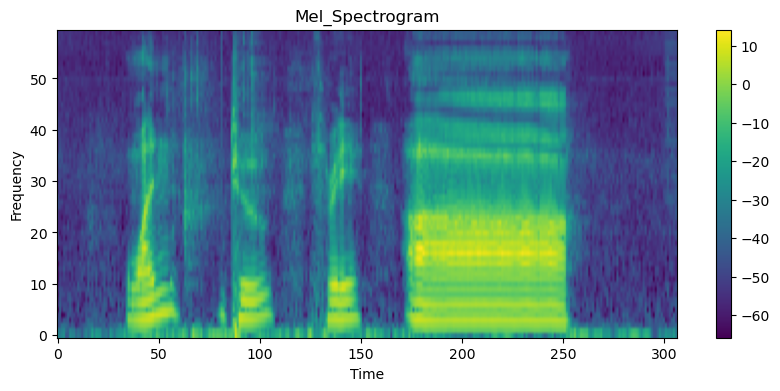

In [13]:
from datasets import Dataset
import numpy as np
import matplotlib.pyplot as plt
ds = Dataset.from_parquet("/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/filtered/torchaudio_mel_spectrogram_filtered.parquet")
import librosa
spectrogram = librosa.power_to_db(np.asarray(ds[93]['mel_spectrogram']))
plt.figure(figsize=(10, 4))
plt.imshow(spectrogram, aspect='auto', origin='lower')
plt.title('Mel_Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar()

#### 5. Check Mel Spectrogram T (recording length) consistency.

In [2]:
import pyarrow.parquet as pq
import pyarrow.compute as pc
import pandas as pd

parquet_path = "/home/taor/work/bridge2AI-data/Gituploading/dataset/merged_data/Patien_Control_merge_spectrogram.parquet" #merged parkinson and control data
pf = pq.ParquetFile(parquet_path)

# read n_frames + task_name
rows = []
for b in pf.iter_batches(batch_size=4096, columns=["task_name", "n_frames"]):
    t = b.to_pydict()
    for task, nf in zip(t["task_name"], t["n_frames"]):
        if task == "prolonged-vowel":
            rows.append(nf)

s = pd.Series(rows)
print("N=", len(s))
print("p50=", s.quantile(0.5), "p95=", s.quantile(0.95), "min=", s.min(), "max=", s.max())

N= 290
p50= 607.0 p95= 607.0 min= 209 max= 641


#### 6. Load and check data for Conv2D training

In [6]:
import pyarrow.parquet as pq
import numpy as np
import torch
from torch.utils.data import Dataset

class MelInMemoryDataset(Dataset):
    def __init__(self, parquet_path, ctrl_ids, pat_ids, T0=512, train=True, log1p=True):
        self.T0 = T0
        self.train = train
        self.log1p = log1p

        ctrl_ids = set(ctrl_ids)
        pat_ids = set(pat_ids)

        table = pq.read_table(parquet_path, columns=["participant_id","task_name","mel_spectrogram"])
        d = table.to_pydict()

        X, Y, P = [], [], []
        for pid, task, mel in zip(d["participant_id"], d["task_name"], d["mel_spectrogram"]):
            pid = str(pid).strip()
            if task != "prolonged-vowel":
                continue
            if pid in ctrl_ids:
                y = 0
            elif pid in pat_ids:
                y = 1
            else:
                continue

            x = np.asarray(mel, dtype=np.float32)  # (60, T)
            if self.log1p:
                x = np.log1p(np.maximum(x, 0.0))
            x = pad_or_crop(x, T0=self.T0, train=self.train)
            x = per_bin_standardize(x)
            X.append(x)
            Y.append(y)
            P.append(pid)

        self.X = torch.from_numpy(np.stack(X)).unsqueeze(1)  # [N,1,60,T0]
        self.Y = torch.tensor(Y, dtype=torch.long)
        self.P = P
        print(f"[INFO] in-memory dataset: N={len(self.Y)}  pos={int(self.Y.sum())}  neg={len(self.Y)-int(self.Y.sum())}")

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.P[idx]

In [7]:
import numpy as np

def pad_or_crop(x, T0, train=True):
    """
    x: np.ndarray, shape (60, T)
    return: shape (60, T0)
    """
    C, T = x.shape
    if T == T0:
        return x
    if T > T0:
        # train random crop；eval central crop
        if train:
            start = np.random.randint(0, T - T0 + 1)
        else:
            start = (T - T0) // 2
        return x[:, start:start + T0]
    else:
        out = np.zeros((C, T0), dtype=x.dtype)
        out[:, :T] = x
        return out

def per_bin_standardize(x, eps=1e-6):
    """
    x: np.ndarray, shape (60, T0)
    normalize each mel bin in time-dimension
    """
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True)
    return (x - m) / (s + eps)

from torch.utils.data import DataLoader

ds = MelInMemoryDataset(
    parquet_path="/home/taor/work/bridge2AI-data/Gituploading/dataset/merged_data/Patien_Control_merge_spectrogram.parquet",
    ctrl_ids=ctrl_ids,
    pat_ids=pat_ids,
    T0=512,
    train=True
)

loader = DataLoader(ds, batch_size=16, shuffle=True)
xb, yb, pidb = next(iter(loader))
print(xb.shape, yb.shape, pidb[:3])
# expected results：torch.Size([16, 1, 60, 512])

[INFO] in-memory dataset: N=290  pos=142  neg=148
torch.Size([16, 1, 60, 512]) torch.Size([16]) ('291813', '626357', '260036')


#### 7. Train CNN model with Recall Preference and 5-fold CV

In [8]:
import os, random
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.metrics import accuracy_score, f1_score

# ------------------
# Directory Setting
# ------------------
PARQUET_PATH = "/home/taor/work/bridge2AI-data/Gituploading/dataset/merged_data/Patien_Control_merge_spectrogram.parquet"
CONTROL_TSV  = "/home/taor/work/bridge2AI-data/Gituploading/dataset/phenotype/diagnosis/control.tsv"
PATIENT_TSV  = "/home/taor/work/bridge2AI-data/Gituploading/dataset/phenotype/diagnosis/parkinsons_disease.tsv"
TASK = "prolonged-vowel"

T0 = 607              # based on p50/p95
BATCH_SIZE = 16
EPOCHS = 40
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 8          # early stopping
N_SPLITS = 5
SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def read_ids(tsv_path):
    df = pd.read_csv(tsv_path, sep="\t", dtype=str)
    if "participant_id" in df.columns:
        s = df["participant_id"]
    else:
        s = df.iloc[:, 0]
    return set(s.astype(str).str.strip().dropna().tolist())


def per_bin_standardize(x, eps=1e-6):
    # x: (60, T)
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True)
    return (x - m) / (s + eps)


def pad_or_crop(x, T0, train=True):
    # x: (60, T)
    C, T = x.shape
    if T == T0:
        return x
    if T > T0:
        if train:
            start = np.random.randint(0, T - T0 + 1)
        else:
            start = (T - T0) // 2
        return x[:, start:start + T0]
    else:
        out = np.zeros((C, T0), dtype=x.dtype)
        out[:, :T] = x
        return out


def load_mel_samples(parquet_path, ctrl_ids, pat_ids, task=TASK):
    table = pq.read_table(parquet_path, columns=["participant_id","task_name","mel_spectrogram","n_frames"])
    d = table.to_pydict()

    X_raw = []
    y = []
    pids = []
    lengths = []
    skipped = []

    for pid, tname, mel, nf in zip(d["participant_id"], d["task_name"], d["mel_spectrogram"], d["n_frames"]):
        pid = str(pid).strip()
        if tname != task:
            continue

        if pid in ctrl_ids:
            label = 0
        elif pid in pat_ids:
            label = 1
        else:
            continue

        # Skip missing and outlier
        if mel is None:
            skipped.append((pid, "mel None"))
            continue
        x = np.asarray(mel, dtype=np.float32)
        if x.ndim != 2 or x.shape[0] != 60 or x.shape[1] == 0:
            skipped.append((pid, f"bad shape {x.shape}"))
            continue
        # skip nf/T inconsistency
        if int(nf) != x.shape[1]:
            skipped.append((pid, f"n_frames mismatch {nf} vs {x.shape[1]}"))
            continue

        X_raw.append(x)      
        y.append(label)
        pids.append(pid)
        lengths.append(x.shape[1])

    if len(X_raw) == 0:
        raise ValueError("No sample：check task_name、ID 、parquet column name。")

    print(f"[INFO] loaded N={len(X_raw)}  pos={sum(y)}  neg={len(y)-sum(y)}  skipped={len(skipped)}")
    if skipped:
        print("[INFO] skipped examples:", skipped[:10])
    return X_raw, np.array(y, dtype=int), pids, np.array(lengths, dtype=int)


class MelDataset(Dataset):
    def __init__(self, X_raw, y, indices, T0=607, train=True, use_log1p=False):
        self.X_raw = X_raw
        self.y = y
        self.idx = np.array(indices, dtype=int)
        self.T0 = T0
        self.train = train
        self.use_log1p = use_log1p

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        x = self.X_raw[j]  # (60, T)

        
        if self.use_log1p:
            x = np.log1p(np.maximum(x, 0.0))

        
        x = per_bin_standardize(x)

        
        x = pad_or_crop(x, self.T0, train=self.train)

        # to tensor: [1, 60, T0]
        x = torch.from_numpy(x).unsqueeze(0).float()
        y = torch.tensor(self.y[j]).long()
        return x, y


class SmallCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),   # -> [16, 30, ~T/2]

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),   # -> [32, 15, ~T/4]

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / max(n, 1)


@torch.no_grad()
def eval_model(model, loader, device):
    model.eval()
    probs = []
    ys = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(p)
        ys.append(yb.numpy())
    probs = np.concatenate(probs)
    ys = np.concatenate(ys)
    return ys, probs
from sklearn.metrics import precision_score, recall_score

def pick_threshold_for_min_recall(y_true, p_pred, min_recall=0.85):
    """
    check thrs：make recall >= min_recall，and as high as possible
    return: best_thr, (best_precision, best_recall)
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)

  
    thresholds = np.unique(np.quantile(p_pred, np.linspace(0.0, 1.0, 201)))
    best = None  # (precision, recall, thr)

    for thr in thresholds:
        y_hat = (p_pred >= thr).astype(int)
        rec = recall_score(y_true, y_hat, zero_division=0)
        if rec < min_recall:
            continue
        pre = precision_score(y_true, y_hat, zero_division=0)
        cand = (pre, rec, float(thr))
        if best is None or cand[0] > best[0] + 1e-12: 
            best = cand

    # maximize recell if recall thrs does not meet
    if best is None:
        best_rec = -1
        best_pre = -1
        best_thr = 0.0
        for thr in thresholds:
            y_hat = (p_pred >= thr).astype(int)
            rec = recall_score(y_true, y_hat, zero_division=0)
            pre = precision_score(y_true, y_hat, zero_division=0)
            if rec > best_rec + 1e-12:
                best_rec, best_pre, best_thr = rec, pre, float(thr)
        return best_thr, (best_pre, best_rec)

    return best[2], (best[0], best[1])

def main():
    set_seed(SEED)

    ctrl_ids = read_ids(CONTROL_TSV)
    pat_ids  = read_ids(PATIENT_TSV)

    overlap = ctrl_ids & pat_ids
    if len(overlap) != 0:
        raise ValueError(f"find control/patient ID overlap: {len(overlap)}，remove duplicate，：{list(overlap)[:10]}")

    X_raw, y, pids, lengths = load_mel_samples(PARQUET_PATH, ctrl_ids, pat_ids, TASK)
    print(f"[INFO] n_frames: p50={np.quantile(lengths,0.5)}  p95={np.quantile(lengths,0.95)}  min={lengths.min()}  max={lengths.max()}")
    print(f"[INFO] Using T0={T0}")

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    fold_rows = []
    all_aurocs, all_pre, all_rec, all_acc, all_f1 = [], [], [], [], []

    for fold, (tr, va) in enumerate(skf.split(np.zeros_like(y), y), 1):
        print(f"\n===== Fold {fold}/{N_SPLITS} =====")

        ds_tr = MelDataset(X_raw, y, tr, T0=T0, train=True,  use_log1p=False)
        ds_va = MelDataset(X_raw, y, va, T0=T0, train=False, use_log1p=False)

        dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
        dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

        model = SmallCNN().to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        best_auc = -1.0
        best_state = None
        patience = 0

        for epoch in range(1, EPOCHS + 1):
            loss = train_one_epoch(model, dl_tr, optimizer, DEVICE)
            y_va, p_va = eval_model(model, dl_va, DEVICE)

            auc = roc_auc_score(y_va, p_va)
            print(f"epoch {epoch:03d}  loss={loss:.4f}  val_AUROC={auc:.4f}")

            if auc > best_auc + 1e-4:
                best_auc = auc
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience = 0
            else:
                patience += 1
                if patience >= PATIENCE:
                    print(f"[EARLY STOP] best_AUROC={best_auc:.4f}")
                    break

       
        model.load_state_dict(best_state)
        
        y_tr, p_tr = eval_model(model, dl_tr, DEVICE)     
        thr, (pre_tr, rec_tr) = pick_threshold_for_min_recall(y_tr, p_tr, min_recall=0.85)
        print(f"[FOLD {fold}] picked thr={thr:.4f} on train  (Precision={pre_tr:.3f}, Recall={rec_tr:.3f})")

        
        y_va, p_va = eval_model(model, dl_va, DEVICE)
        auc = roc_auc_score(y_va, p_va)
        y_hat = (p_va >= thr).astype(int)
        pre = precision_score(y_va, y_hat, zero_division=0)
        rec = recall_score(y_va, y_hat, zero_division=0)
        acc = accuracy_score(y_va, y_hat)
        f1  = f1_score(y_va, y_hat, zero_division=0)
        print(f"[FOLD {fold}] AUROC={auc:.4f}  Precision={pre:.4f}  Recall={rec:.4f}")

        fold_rows.append({"fold": fold, "AUROC": auc, "Precision": pre, "Recall": rec,"Accuracy": acc,"F1": f1})
        all_aurocs.append(auc); all_pre.append(pre); all_rec.append(rec);all_acc.append(acc);all_f1.append(f1)

    df = pd.DataFrame(fold_rows)
    df.to_csv("cnn_mel_5fold_results.csv", index=False)

    print("\n===== Summary =====")
    print(df)
    print(f"AUROC    mean±std = {np.mean(all_aurocs):.4f} ± {np.std(all_aurocs):.4f}")
    print(f"Precision mean±std = {np.mean(all_pre):.4f} ± {np.std(all_pre):.4f}")
    print(f"Recall    mean±std = {np.mean(all_rec):.4f} ± {np.std(all_rec):.4f}")
    print(f"Accurarcy  mean±std = {np.mean(all_acc):.4f} ± {np.std(all_acc):.4f}")
    print(f"F1 SCORE  mean±std = {np.mean(all_f1):.4f} ± {np.std(all_f1):.4f}")
    print("[DONE] saved -> cnn_mel_5fold_results.csv")


if __name__ == "__main__":
    main()

[INFO] loaded N=290  pos=142  neg=148  skipped=0
[INFO] n_frames: p50=607.0  p95=607.0  min=209  max=641
[INFO] Using T0=607

===== Fold 1/5 =====
epoch 001  loss=0.6979  val_AUROC=0.7488
epoch 002  loss=0.6851  val_AUROC=0.7512
epoch 003  loss=0.6761  val_AUROC=0.7762
epoch 004  loss=0.6714  val_AUROC=0.7881
epoch 005  loss=0.6641  val_AUROC=0.7667
epoch 006  loss=0.6637  val_AUROC=0.7845
epoch 007  loss=0.6526  val_AUROC=0.7929
epoch 008  loss=0.6514  val_AUROC=0.7917
epoch 009  loss=0.6430  val_AUROC=0.7738
epoch 010  loss=0.6360  val_AUROC=0.7845
epoch 011  loss=0.6369  val_AUROC=0.7762
epoch 012  loss=0.6274  val_AUROC=0.7488
epoch 013  loss=0.6192  val_AUROC=0.7631
epoch 014  loss=0.6164  val_AUROC=0.7643
epoch 015  loss=0.6177  val_AUROC=0.7702
[EARLY STOP] best_AUROC=0.7929
[FOLD 1] picked thr=0.4202 on train  (Precision=0.590, Recall=0.860)
[FOLD 1] AUROC=0.7929  Precision=0.6316  Recall=0.8571

===== Fold 2/5 =====
epoch 001  loss=0.7191  val_AUROC=0.6060
epoch 002  loss=0.69

#### 8. Data visualization for static features
##### Refer to findStaticOutliers.py
#### 9. Try different model to learn relationship between static features.
##### Refer to tryTrainForStaticFeature.py. Results suggest that Catboost has the best performance among all models

#### 10. Merge Catboost and CNN with platt scaling and weight grid search

In [14]:
import os, random
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier


# =========================
# 1) Directory Setting
# =========================
MEL_PARQUET = "/home/taor/work/bridge2AI-data/Gituploading/dataset/merged_data/Patien_Control_merge_spectrogram.parquet"  # mel parquet
TASK = "prolonged-vowel"
CONTROL_STATIC_TSV = "/home/taor/work/bridge2AI-data/Gituploading/dataset/control_data/vowel_task_data/static_control_prolonged-vowel.tsv"
PATIENT_STATIC_TSV = "/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/static_parkinson_prolonged-vowel.tsv"

#  p50=p95=607 -> 607
T0 = 607

# CNN parameters
BATCH_SIZE = 16
EPOCHS = 40
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 8

# CV parameters
N_SPLITS = 5
SEED = 42

# recall thres
MIN_RECALL = 0.85

# Merge
W_GRID = np.linspace(0, 1, 21)  # weighted average 的 w 搜索：0~1 步长0.05

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# 2) Toolkit parameters
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def read_ids(tsv_path):
    df = pd.read_csv(tsv_path, sep="\t", dtype=str)
    if "participant_id" in df.columns:
        s = df["participant_id"]
    else:
        s = df.iloc[:, 0]
    return set(s.astype(str).str.strip().dropna().tolist())


def per_bin_standardize(x, eps=1e-6):
    # x: (60, T)
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True)
    return (x - m) / (s + eps)


def pad_or_crop(x, T0, train=True):
    # x: (60, T)
    C, T = x.shape
    if T == T0:
        return x
    if T > T0:
        if train:
            start = np.random.randint(0, T - T0 + 1)
        else:
            start = (T - T0) // 2
        return x[:, start:start + T0]
    else:
        out = np.zeros((C, T0), dtype=x.dtype)
        out[:, :T] = x
        return out


def pick_threshold_for_min_recall(y_true, p_pred, min_recall=0.85):
    """
    Recall preference setting
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)

    thresholds = np.unique(np.quantile(p_pred, np.linspace(0.0, 1.0, 201)))
    best = None  # (precision, recall, thr)

    for thr in thresholds:
        y_hat = (p_pred >= thr).astype(int)
        rec = recall_score(y_true, y_hat, zero_division=0)
        if rec < min_recall:
            continue
        pre = precision_score(y_true, y_hat, zero_division=0)
        cand = (pre, rec, float(thr))
        if best is None or cand[0] > best[0] + 1e-12:
            best = cand

    if best is not None:
        return best[2]

    # 达不到 min_recall：选 recall 最大的阈值
    best_rec, best_pre, best_thr = -1, -1, 0.0
    for thr in thresholds:
        y_hat = (p_pred >= thr).astype(int)
        rec = recall_score(y_true, y_hat, zero_division=0)
        pre = precision_score(y_true, y_hat, zero_division=0)
        if rec > best_rec + 1e-12:
            best_rec, best_pre, best_thr = rec, pre, float(thr)
    return best_thr


def fit_platt_calibrator(y, p):
    """
    Platt scaling with logistic regression
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float).reshape(-1, 1)
    lr = LogisticRegression(solver="liblinear", max_iter=200)
    lr.fit(p, y)
    return lr


def apply_calibrator(calibrator, p):
    p = np.asarray(p).astype(float).reshape(-1, 1)
    return calibrator.predict_proba(p)[:, 1]


# =========================
# 3) read data
# =========================
def load_mel_samples(parquet_path, ctrl_ids, pat_ids, task=TASK):
    table = pq.read_table(parquet_path, columns=["participant_id","task_name","mel_spectrogram","n_frames"])
    d = table.to_pydict()

    X_raw, y, pids, lengths = [], [], [], []
    skipped = []

    for pid, tname, mel, nf in zip(d["participant_id"], d["task_name"], d["mel_spectrogram"], d["n_frames"]):
        pid = str(pid).strip()
        if tname != task:
            continue

        if pid in ctrl_ids:
            label = 0
        elif pid in pat_ids:
            label = 1
        else:
            continue

        if mel is None:
            skipped.append((pid, "mel None"))
            continue

        x = np.asarray(mel, dtype=np.float32)
        if x.ndim != 2 or x.shape[0] != 60 or x.shape[1] == 0:
            skipped.append((pid, f"bad shape {x.shape}"))
            continue
        if int(nf) != x.shape[1]:
            skipped.append((pid, f"n_frames mismatch {nf} vs {x.shape[1]}"))
            continue

        X_raw.append(x)
        y.append(label)
        pids.append(pid)
        lengths.append(x.shape[1])

    if len(X_raw) == 0:
        raise ValueError("No sample read：check parquet column name、task_name、control/patient ID。")

    print(f"[INFO] mel samples: N={len(X_raw)} pos={sum(y)} neg={len(y)-sum(y)} skipped={len(skipped)}")
    if skipped:
        print("[INFO] skipped examples:", skipped[:10])
    lengths = np.array(lengths, dtype=int)
    print(f"[INFO] n_frames: p50={np.quantile(lengths,0.5)} p95={np.quantile(lengths,0.95)} min={lengths.min()} max={lengths.max()}")
    return X_raw, np.array(y, dtype=int), pids


# =========================
# 4) align with static features
# =========================
def load_static_aligned(control_tsv, patient_tsv, pids, task=TASK):
    c = pd.read_csv(control_tsv, sep="\t", dtype=str)
    p = pd.read_csv(patient_tsv, sep="\t", dtype=str)
    c["label"] = 0
    p["label"] = 1

    common = sorted(set(c.columns) & set(p.columns))
    df = pd.concat([c[common], p[common]], ignore_index=True)

    if "task_name" in df.columns:
        df["task_name"] = df["task_name"].astype(str).str.strip()
        df = df[df["task_name"] == task].copy()

    if "participant_id" not in df.columns:
        raise ValueError("static TSV with no participant_id 列")

    df["participant_id"] = df["participant_id"].astype(str).str.strip()
    df = df.drop_duplicates(subset=["participant_id"]).set_index("participant_id")

    # align pid order
    missing = [pid for pid in pids if pid not in df.index]
    if len(missing) > 0:
        print(f"[WARN] static lack {len(missing)} pid（merge failure）：example {missing[:10]}")

    df_aligned = df.loc[[pid for pid in pids if pid in df.index]].copy()
    aligned_pids = df_aligned.index.tolist()

    # exclude missing data
    drop_cols = {"label", "session_id", "task_name","transcription"}
    feat_cols = [c for c in df_aligned.columns if c not in drop_cols]

    X = df_aligned[feat_cols].apply(pd.to_numeric, errors="coerce")
    y = df_aligned["label"].astype(int).values

    return X, y, aligned_pids


# =========================
# 5) PyTorch Dataset + CNN
# =========================
class MelDataset(Dataset):
    def __init__(self, X_raw, y, indices, T0=T0, train=True, use_log1p=False):
        self.X_raw = X_raw
        self.y = y
        self.idx = np.array(indices, dtype=int)
        self.T0 = T0
        self.train = train
        self.use_log1p = use_log1p

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        x = self.X_raw[j]  # (60, T)

        if self.use_log1p:
            x = np.log1p(np.maximum(x, 0.0))

        x = per_bin_standardize(x)
        x = pad_or_crop(x, self.T0, train=self.train)

        x = torch.from_numpy(x).unsqueeze(0).float()  # [1,60,T0]
        y = torch.tensor(self.y[j]).long()
        return x, y


class SmallCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


def train_one_epoch(model, loader, optimizer):
    model.train()
    total, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / max(n, 1)


@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    probs, ys = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(p)
        ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(probs)


def fit_cnn_on_fold(X_raw, y, tr_idx, va_idx):
    # train loader（随机裁剪）
    ds_tr = MelDataset(X_raw, y, tr_idx, T0=T0, train=True)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

    # eval loader（中心裁剪）用于 early stopping
    ds_va = MelDataset(X_raw, y, va_idx, T0=T0, train=False)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    model = SmallCNN().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_auc = -1.0
    best_state = None
    patience = 0

    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, dl_tr, opt)
        y_va, p_va = predict_proba(model, dl_va)
        auc = roc_auc_score(y_va, p_va)

        if auc > best_auc + 1e-4:
            best_auc = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model


# =========================
# 6) CatBoost training
# =========================
def fit_catboost_on_fold(X, y, tr_idx):
    model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        random_seed=SEED,
        verbose=False
    )
    model.fit(X.iloc[tr_idx], y[tr_idx])
    return model


# =========================
# 7) Core metrics
# =========================
def compute_metrics(y_true, p_pred, thr):
    y_hat = (p_pred >= thr).astype(int)
    return {
        "AUROC": roc_auc_score(y_true, p_pred),
        "Precision": precision_score(y_true, y_hat, zero_division=0),
        "Recall": recall_score(y_true, y_hat, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_hat),
        "F1": f1_score(y_true, y_hat, zero_division=0),
    }


# =========================
# 8) Training and merge
# =========================
def main():
    set_seed(SEED)
    print(f"[INFO] device={DEVICE}")

    ctrl_ids = read_ids(CONTROL_STATIC_TSV)
    pat_ids = read_ids(PATIENT_STATIC_TSV)

    overlap = ctrl_ids & pat_ids
    if len(overlap) > 0:
        raise ValueError(f"find control/patient ID overlap={len(overlap)}，exmaple：{list(overlap)[:10]}")

   
    X_raw, y_mel, pids_mel = load_mel_samples(MEL_PARQUET, ctrl_ids, pat_ids, TASK)

 
    X_static, y_static, pids_static = load_static_aligned(CONTROL_STATIC_TSV, PATIENT_STATIC_TSV, pids_mel, TASK)

  
    pid_to_mel_idx = {pid: i for i, pid in enumerate(pids_mel)}
    keep_mel_idx = [pid_to_mel_idx[pid] for pid in pids_static]
    X_raw = [X_raw[i] for i in keep_mel_idx]
    y = np.array([y_mel[i] for i in keep_mel_idx], dtype=int)
    pids = pids_static

  
    if not np.array_equal(y, y_static):
        raise ValueError("mel 与 static 对齐后标签不一致，请检查 ID 划分/过滤逻辑。")

    print(f"[INFO] final aligned N={len(y)} pos={y.sum()} neg={len(y)-y.sum()}")

  
    pd.DataFrame({"participant_id": pids, "y": y}).to_csv("sample_index.tsv", sep="\t", index=False)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    # 
    p_cnn_oof = np.zeros(len(y), dtype=float)
    p_cb_oof = np.zeros(len(y), dtype=float)

    # 
    fold_rows_weighted = []
    fold_rows_stacking = []
    cnn_stats_all = []
    cb_stats_all = []

    for fold, (tr, va) in enumerate(skf.split(np.zeros_like(y), y), 1):
        
        print(f"\n===== Fold {fold}/{N_SPLITS} =====")

        # ---- CNN ----
        cnn = fit_cnn_on_fold(X_raw, y, tr, va)

        dl_tr_eval = DataLoader(MelDataset(X_raw, y, tr, T0=T0, train=False), batch_size=BATCH_SIZE, shuffle=False)
        dl_va_eval = DataLoader(MelDataset(X_raw, y, va, T0=T0, train=False), batch_size=BATCH_SIZE, shuffle=False)

        y_tr, p_tr_cnn = predict_proba(cnn, dl_tr_eval)
        y_va, p_va_cnn = predict_proba(cnn, dl_va_eval)

        # ---- CatBoost ----
        cb = fit_catboost_on_fold(X_static, y, tr)
        p_tr_cb = cb.predict_proba(X_static.iloc[tr])[:, 1]
        p_va_cb = cb.predict_proba(X_static.iloc[va])[:, 1]

        # ---- Calibration----
        # 20% in training set for calibration
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED + fold)
        tr_pos = np.arange(len(tr))
        fit_pos, cal_pos = next(sss.split(tr_pos, y[tr]))

   
        y_cal = y[tr][cal_pos]

        p_cal_cnn = p_tr_cnn[cal_pos]
        cal_cnn = fit_platt_calibrator(y_cal, p_cal_cnn)
        p_tr_cnn_cal = apply_calibrator(cal_cnn, p_tr_cnn)
        p_va_cnn_cal = apply_calibrator(cal_cnn, p_va_cnn)

        p_cal_cb = p_tr_cb[cal_pos]
        cal_cb = fit_platt_calibrator(y_cal, p_cal_cb)
        p_tr_cb_cal = apply_calibrator(cal_cb, p_tr_cb)
        p_va_cb_cal = apply_calibrator(cal_cb, p_va_cb)

        # save OOF
        p_cnn_oof[va] = p_va_cnn_cal
        p_cb_oof[va] = p_va_cb_cal

        # CNN
        thr_cnn = pick_threshold_for_min_recall(y[tr], p_tr_cnn_cal, min_recall=MIN_RECALL)
        stats_cnn = compute_metrics(y[va], p_va_cnn_cal, thr_cnn)
        stats_cnn["fold"] = fold
        stats_cnn["thr"] = float(thr_cnn)
        cnn_stats_all.append(stats_cnn)

        # CatBoost
        thr_cb = pick_threshold_for_min_recall(y[tr], p_tr_cb_cal, min_recall=MIN_RECALL)
        stats_cb = compute_metrics(y[va], p_va_cb_cal, thr_cb)
        stats_cb["fold"] = fold
        stats_cb["thr"] = float(thr_cb)
        cb_stats_all.append(stats_cb)

        print(f"[INFO] fold {fold} base OOF saved (cnn+cb)")

    # save OOF
    pd.DataFrame({
        "participant_id": pids,
        "y": y,
        "p_cnn": p_cnn_oof,
        "p_catboost": p_cb_oof
    }).to_csv("oof_probs.tsv", sep="\t", index=False)

    pd.DataFrame(cnn_stats_all).to_csv("cnn_results.csv", index=False)
    pd.DataFrame(cb_stats_all).to_csv("catboost_results.csv", index=False)
    print("\n[DONE] saved -> oof_probs.tsv")
    

    # =========================
    # 8A) merge1：Weighted Average（search best w）
    # =========================
    best_w = None
    best_score = -1
    best_weighted_stats = None

    for w in W_GRID:
        fold_stats = []
        for fold, (tr, va) in enumerate(skf.split(np.zeros_like(y), y), 1):
            p_tr = w*p_cnn_oof[tr] + (1-w)*p_cb_oof[tr]
            thr = pick_threshold_for_min_recall(y[tr], p_tr, min_recall=MIN_RECALL)

            p_va = w*p_cnn_oof[va] + (1-w)*p_cb_oof[va]
            stats = compute_metrics(y[va], p_va, thr)
            stats["fold"] = fold
            stats["w"] = float(w)
            stats["thr"] = float(thr)
            fold_stats.append(stats)

        mean_recall = np.mean([d["Recall"] for d in fold_stats])
        mean_prec = np.mean([d["Precision"] for d in fold_stats])
        score = mean_recall + 0.2*mean_prec  
        if score > best_score:
            best_score = score
            best_w = w
            best_weighted_stats = fold_stats

    df_w = pd.DataFrame(best_weighted_stats)
    df_w.to_csv("fusion_weighted_results.csv", index=False)
    print(f"\n[WEIGHTED] best_w={best_w:.2f} saved -> fusion_weighted_results.csv")
    print(df_w[["fold","AUROC","Precision","Recall","Accuracy","F1","w","thr"]])

    # =========================
    # 8B) merge2：Stacking（LogisticRegression on (p_cnn, p_cb)）
    # =========================
    meta = np.vstack([p_cnn_oof, p_cb_oof]).T  # [N,2]
    stack_stats = []

    for fold, (tr, va) in enumerate(skf.split(meta, y), 1):
        lr = LogisticRegression(solver="liblinear", max_iter=500)
        lr.fit(meta[tr], y[tr])

        p_tr = lr.predict_proba(meta[tr])[:, 1]
        thr = pick_threshold_for_min_recall(y[tr], p_tr, min_recall=MIN_RECALL)

        p_va = lr.predict_proba(meta[va])[:, 1]
        stats = compute_metrics(y[va], p_va, thr)
        stats["fold"] = fold
        stats["thr"] = float(thr)
        stack_stats.append(stats)

    df_s = pd.DataFrame(stack_stats)
    df_s.to_csv("fusion_stacking_results.csv", index=False)
    print("\n[STACKING] saved -> fusion_stacking_results.csv")
    print(df_s[["fold","AUROC","Precision","Recall","Accuracy","F1","thr"]])

    # Summary
    def summarize(df, name):
        print(f"\n===== {name} Summary (mean±std) =====")
        for k in ["AUROC","Precision","Recall","Accuracy","F1"]:
            print(f"{k:9s} = {df[k].mean():.4f} ± {df[k].std():.4f}")

    summarize(df_w, f"Weighted (w={best_w:.2f})")
    summarize(df_s, "Stacking")
    # =========================

if __name__ == "__main__":
    main()

[INFO] device=cuda
[INFO] mel samples: N=290 pos=142 neg=148 skipped=0
[INFO] n_frames: p50=607.0 p95=607.0 min=209 max=641
[INFO] final aligned N=290 pos=142 neg=148

===== Fold 1/5 =====
[INFO] fold 1 base OOF saved (cnn+cb)

===== Fold 2/5 =====
[INFO] fold 2 base OOF saved (cnn+cb)

===== Fold 3/5 =====
[INFO] fold 3 base OOF saved (cnn+cb)

===== Fold 4/5 =====
[INFO] fold 4 base OOF saved (cnn+cb)

===== Fold 5/5 =====
[INFO] fold 5 base OOF saved (cnn+cb)

[DONE] saved -> oof_probs.tsv

[WEIGHTED] best_w=0.55 saved -> fusion_weighted_results.csv
   fold     AUROC  Precision    Recall  Accuracy        F1     w       thr
0     1  0.885714   0.814815  0.785714  0.810345  0.800000  0.55  0.451453
1     2  0.829762   0.777778  0.750000  0.775862  0.763636  0.55  0.451309
2     3  0.852381   0.642857  0.964286  0.724138  0.771429  0.55  0.413940
3     4  0.860880   0.702703  0.896552  0.758621  0.787879  0.55  0.418404
4     5  0.884661   0.722222  0.896552  0.775862  0.800000  0.55  

#### 11. Extract Multimodal Embeddings (CNN + CatBoost) for Downstream Fusion
##### This cell re-runs the same 5-fold CV loop from Cell 10, but instead of saving only probabilities,
##### it extracts intermediate representations from both models:
##### - **CNN embedding**: 64-dim vector from `AdaptiveAvgPool2d` (before the FC head)
##### - **CatBoost embedding**: concatenation of `predict_proba` (2-dim) + `calc_leaf_indexes` (n_trees-dim, hashed to fixed size)
##### The final OOF embedding matrix is saved as `multimodal_embeddings_oof.npz` for use in a downstream multimodal model.

[INFO] mel N=290 pos=142 neg=148
[INFO] aligned N=290 pos=142 neg=148

===== Embedding Fold 1/5 =====
[INFO] CatBoost leaf dim = 128
[INFO] Fold 1 — cnn (58, 64), cb_proba (58, 2), cb_leaf (58, 128)

===== Embedding Fold 2/5 =====
[INFO] Fold 2 — cnn (58, 64), cb_proba (58, 2), cb_leaf (58, 128)

===== Embedding Fold 3/5 =====
[INFO] Fold 3 — cnn (58, 64), cb_proba (58, 2), cb_leaf (58, 128)

===== Embedding Fold 4/5 =====
[INFO] Fold 4 — cnn (58, 64), cb_proba (58, 2), cb_leaf (58, 128)

===== Embedding Fold 5/5 =====
[INFO] Fold 5 — cnn (58, 64), cb_proba (58, 2), cb_leaf (58, 128)

[INFO] concat embedding shape: (290, 194) = CNN(64) + CB_proba(2) + CB_leaf(128)
[DONE] Saved -> multimodal_embeddings_oof.npz


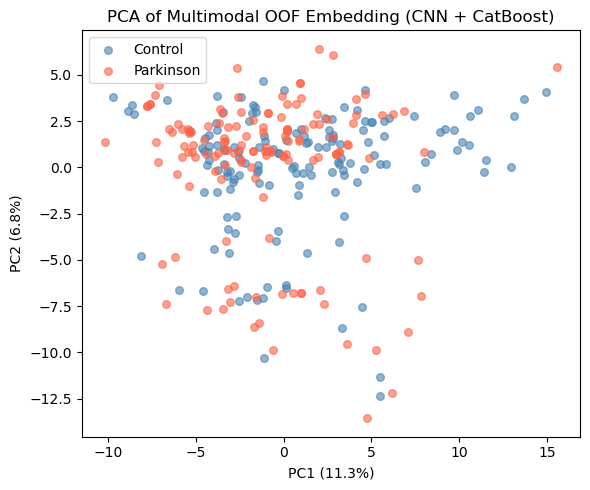

[INFO] Running UMAP (this may take ~30s)...


/public/taoran/apps/mamba/envs/eda/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


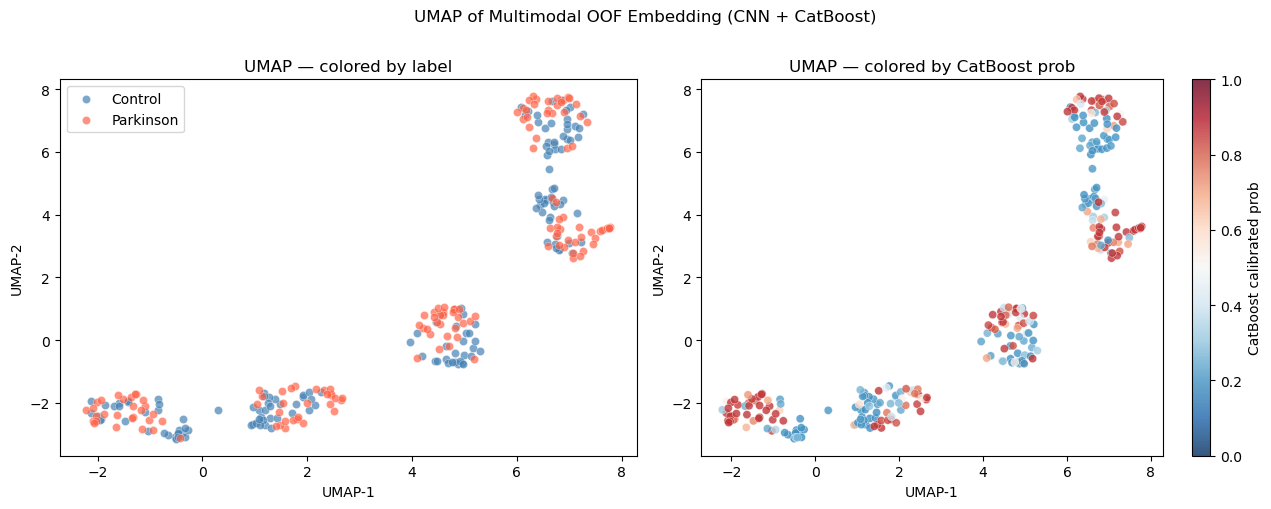

[INFO] UMAP plot saved -> multimodal_embedding_umap.png
Load in downstream model:
  data   = np.load('multimodal_embeddings_oof.npz', allow_pickle=True)
  X_all  = data['emb_concat']    # (N, 194) full multimodal embedding
  X_cnn  = data['emb_cnn']       # (N,  64) acoustic / temporal
  X_prob = data['emb_cb_proba']  # (N,   2) static-feature probability
  X_leaf = data['emb_cb_leaf']   # (N, 128) tree structure signal
  y      = data['y']             # (N,) labels
  pids   = data['participant_id']# (N,) participant IDs



In [10]:
# ============================================================
# Cell 11: Extract Multimodal Embeddings (CNN + CatBoost OOF)
# Self-contained — all constants, helpers, and data loading are
# redefined here. Skip Section 3 data loading if X_raw / y /
# pids / X_static are already in memory from Cell 10.
# ============================================================

import os, random
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# ── Section 0: Constants ──────────────────────────────────────────────────────
MEL_PARQUET        = "/home/taor/work/bridge2AI-data/Gituploading/dataset/merged_data/Patien_Control_merge_spectrogram.parquet"
TASK               = "prolonged-vowel"
CONTROL_STATIC_TSV = "/home/taor/work/bridge2AI-data/Gituploading/dataset/control_data/vowel_task_data/static_control_prolonged-vowel.tsv"
PATIENT_STATIC_TSV = "/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/static_parkinson_prolonged-vowel.tsv"

T0           = 607
BATCH_SIZE   = 16
EPOCHS       = 40
LR           = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 8
N_SPLITS     = 5
SEED         = 42
MIN_RECALL   = 0.85
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
CB_LEAF_DIM  = 128  # set None to keep full leaf matrix

# ── Section 1: Helpers ────────────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def read_ids(tsv_path):
    df = pd.read_csv(tsv_path, sep='\t', dtype=str)
    col = 'participant_id' if 'participant_id' in df.columns else df.columns[0]
    return set(df[col].astype(str).str.strip().dropna().tolist())

def per_bin_standardize(x, eps=1e-6):
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True)
    return (x - m) / (s + eps)

def pad_or_crop(x, T0, train=True):
    C, T = x.shape
    if T == T0:
        return x
    if T > T0:
        start = np.random.randint(0, T - T0 + 1) if train else (T - T0) // 2
        return x[:, start:start + T0]
    out = np.zeros((C, T0), dtype=x.dtype)
    out[:, :T] = x
    return out

def pick_threshold_for_min_recall(y_true, p_pred, min_recall=MIN_RECALL):
    from sklearn.metrics import recall_score, precision_score
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)
    thresholds = np.unique(np.quantile(p_pred, np.linspace(0.0, 1.0, 201)))
    best = None
    for thr in thresholds:
        y_hat = (p_pred >= thr).astype(int)
        rec = recall_score(y_true, y_hat, zero_division=0)
        if rec < min_recall:
            continue
        pre = precision_score(y_true, y_hat, zero_division=0)
        cand = (pre, rec, float(thr))
        if best is None or cand[0] > best[0] + 1e-12:
            best = cand
    if best is not None:
        return best[2]
    best_rec, best_thr = -1, 0.0
    for thr in thresholds:
        y_hat = (p_pred >= thr).astype(int)
        rec = recall_score(y_true, y_hat, zero_division=0)
        if rec > best_rec + 1e-12:
            best_rec, best_thr = rec, float(thr)
    return best_thr

def fit_platt_calibrator(y, p):
    p = np.asarray(p).astype(float).reshape(-1, 1)
    lr = LogisticRegression(solver='liblinear', max_iter=200)
    lr.fit(p, np.asarray(y).astype(int))
    return lr

def apply_calibrator(calibrator, p):
    return calibrator.predict_proba(np.asarray(p).reshape(-1, 1))[:, 1]

# ── Section 2: Dataset + Model ────────────────────────────────────────────────
class MelDataset(Dataset):
    def __init__(self, X_raw, y, indices, T0=T0, train=True):
        self.X_raw = X_raw; self.y = y
        self.idx = np.array(indices, dtype=int)
        self.T0 = T0; self.train = train
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        x = per_bin_standardize(self.X_raw[j])
        x = pad_or_crop(x, self.T0, train=self.train)
        return torch.from_numpy(x).unsqueeze(0).float(), torch.tensor(self.y[j]).long()

class SmallCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d((2, 2)),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc   = nn.Linear(64, n_classes)
    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(xb), yb)
        loss.backward(); optimizer.step()
        total += loss.item() * xb.size(0); n += xb.size(0)
    return total / max(n, 1)

@torch.no_grad()
def predict_proba_cnn(model, loader):
    model.eval()
    probs, ys = [], []
    for xb, yb in loader:
        p = torch.softmax(model(xb.to(DEVICE)), dim=1)[:, 1].cpu().numpy()
        probs.append(p); ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(probs)

def fit_cnn_on_fold(X_raw, y, tr_idx, va_idx):
    dl_tr = DataLoader(MelDataset(X_raw, y, tr_idx, T0=T0, train=True),
                       batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    dl_va = DataLoader(MelDataset(X_raw, y, va_idx, T0=T0, train=False),
                       batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    model = SmallCNN().to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best_auc, best_state, patience = -1.0, None, 0
    for epoch in range(1, EPOCHS + 1):
        train_one_epoch(model, dl_tr, opt)
        y_va, p_va = predict_proba_cnn(model, dl_va)
        auc = roc_auc_score(y_va, p_va)
        if auc > best_auc + 1e-4:
            best_auc = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= PATIENCE:
                break
    model.load_state_dict(best_state)
    return model

def fit_catboost_on_fold(X, y, tr_idx):
    model = CatBoostClassifier(
        iterations=1500, learning_rate=0.03, depth=6,
        loss_function='Logloss', random_seed=SEED, verbose=False)
    model.fit(X.iloc[tr_idx], y[tr_idx])
    return model

# ── Section 3: Data loading ───────────────────────────────────────────────────
# Comment out this section if X_raw / y / pids / X_static are already loaded.
def _load_mel(parquet_path, ctrl_ids, pat_ids, task):
    d = pq.read_table(parquet_path,
                      columns=['participant_id','task_name','mel_spectrogram','n_frames']).to_pydict()
    X_raw, y_out, pids = [], [], []
    for pid, tname, mel, nf in zip(d['participant_id'], d['task_name'],
                                   d['mel_spectrogram'], d['n_frames']):
        pid = str(pid).strip()
        if tname != task: continue
        label = 0 if pid in ctrl_ids else (1 if pid in pat_ids else None)
        if label is None or mel is None: continue
        x = np.asarray(mel, dtype=np.float32)
        if x.ndim != 2 or x.shape[0] != 60 or x.shape[1] == 0: continue
        if int(nf) != x.shape[1]: continue
        X_raw.append(x); y_out.append(label); pids.append(pid)
    print(f'[INFO] mel N={len(X_raw)} pos={sum(y_out)} neg={len(y_out)-sum(y_out)}')
    return X_raw, np.array(y_out, dtype=int), pids

def _load_static(ctrl_tsv, pat_tsv, pids, task):
    c = pd.read_csv(ctrl_tsv, sep='\t', dtype=str); c['label'] = 0
    p = pd.read_csv(pat_tsv,  sep='\t', dtype=str); p['label'] = 1
    common = sorted(set(c.columns) & set(p.columns))
    df = pd.concat([c[common], p[common]], ignore_index=True)
    if 'task_name' in df.columns:
        df = df[df['task_name'].astype(str).str.strip() == task].copy()
    df['participant_id'] = df['participant_id'].astype(str).str.strip()
    df = df.drop_duplicates(subset=['participant_id']).set_index('participant_id')
    df_aligned = df.loc[[p for p in pids if p in df.index]].copy()
    drop_cols  = {'label', 'session_id', 'task_name',"transcription"}
    feat_cols  = [c for c in df_aligned.columns if c not in drop_cols]
    return (df_aligned[feat_cols].apply(pd.to_numeric, errors='coerce'),
            df_aligned['label'].astype(int).values,
            df_aligned.index.tolist())

set_seed(SEED)
ctrl_ids = read_ids(CONTROL_STATIC_TSV)
pat_ids  = read_ids(PATIENT_STATIC_TSV)
X_raw_all, y_mel, pids_mel = _load_mel(MEL_PARQUET, ctrl_ids, pat_ids, TASK)
X_static, y_static, pids   = _load_static(CONTROL_STATIC_TSV, PATIENT_STATIC_TSV, pids_mel, TASK)
pid_to_idx = {p: i for i, p in enumerate(pids_mel)}
keep       = [pid_to_idx[p] for p in pids]
X_raw = [X_raw_all[i] for i in keep]
y     = np.array([y_mel[i] for i in keep], dtype=int)
assert np.array_equal(y, y_static), 'label mismatch after alignment!'
print(f'[INFO] aligned N={len(y)} pos={y.sum()} neg={len(y)-y.sum()}')

# ── Section 4: Embedding extractors ──────────────────────────────────────────
@torch.no_grad()
def extract_cnn_embeddings(model, loader):
    model.eval()
    collected = []
    def _hook(module, inp, out):
        collected.append(out.flatten(1).cpu().numpy())
    handle = model.pool.register_forward_hook(_hook)
    try:
        for xb, _ in loader:
            model(xb.to(DEVICE))
    finally:
        handle.remove()
    return np.concatenate(collected, axis=0)  # (N, 64)

def extract_catboost_embeddings(cb_model, X_df, calibrator, leaf_dim):
    p_raw     = cb_model.predict_proba(X_df)[:, 1]
    p_cal     = apply_calibrator(calibrator, p_raw)
    emb_proba = np.stack([1 - p_cal, p_cal], axis=1).astype(np.float32)
    leaf_raw  = cb_model.calc_leaf_indexes(X_df).astype(np.float32)
    if leaf_dim is not None and leaf_dim < leaf_raw.shape[1]:
        rng  = np.random.RandomState(SEED)
        proj = rng.randn(leaf_raw.shape[1], leaf_dim).astype(np.float32) / np.sqrt(leaf_dim)
        emb_leaf = leaf_raw @ proj
    else:
        emb_leaf = leaf_raw
    return emb_proba, emb_leaf

# ── Section 5: OOF loop ───────────────────────────────────────────────────────
set_seed(SEED)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
N   = len(y)

emb_cnn_oof      = np.zeros((N, 64), dtype=np.float32)
emb_cb_proba_oof = np.zeros((N, 2),  dtype=np.float32)
emb_cb_leaf_oof  = None

for fold, (tr, va) in enumerate(skf.split(np.zeros(N), y), 1):
    print(f'\n===== Embedding Fold {fold}/{N_SPLITS} =====')

    cnn = fit_cnn_on_fold(X_raw, y, tr, va)
    dl_va = DataLoader(MelDataset(X_raw, y, va, T0=T0, train=False),
                       batch_size=BATCH_SIZE, shuffle=False)
    emb_cnn_oof[va] = extract_cnn_embeddings(cnn, dl_va)

    cb = fit_catboost_on_fold(X_static, y, tr)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED + fold)
    _, cal_pos = next(sss.split(np.arange(len(tr)), y[tr]))
    y_cal    = y[tr][cal_pos]
    p_cal_cb = cb.predict_proba(X_static.iloc[tr[cal_pos]])[:, 1]
    cal_cb   = fit_platt_calibrator(y_cal, p_cal_cb)

    emb_proba_va, emb_leaf_va = extract_catboost_embeddings(
        cb, X_static.iloc[va], cal_cb, leaf_dim=CB_LEAF_DIM)
    emb_cb_proba_oof[va] = emb_proba_va

    if emb_cb_leaf_oof is None:
        emb_cb_leaf_oof = np.zeros((N, emb_leaf_va.shape[1]), dtype=np.float32)
        print(f'[INFO] CatBoost leaf dim = {emb_leaf_va.shape[1]}')
    emb_cb_leaf_oof[va] = emb_leaf_va

    print(f'[INFO] Fold {fold} — cnn {emb_cnn_oof[va].shape}, '
          f'cb_proba {emb_proba_va.shape}, cb_leaf {emb_leaf_va.shape}')

# ── Section 6: Save ───────────────────────────────────────────────────────────
#emb_concat = np.concatenate([emb_cnn_oof, emb_cb_proba_oof, emb_cb_leaf_oof], axis=1)
from sklearn.preprocessing import StandardScaler
emb_cnn_s  = StandardScaler().fit_transform(emb_cnn_oof)
emb_prob_s = StandardScaler().fit_transform(emb_cb_proba_oof)
emb_leaf_s = StandardScaler().fit_transform(emb_cb_leaf_oof)
emb_concat = np.concatenate([emb_cnn_s, emb_prob_s, emb_leaf_s], axis=1)
print(f'\n[INFO] concat embedding shape: {emb_concat.shape} '
      f'= CNN(64) + CB_proba(2) + CB_leaf({emb_cb_leaf_oof.shape[1]})')

np.savez_compressed(
    'multimodal_embeddings_oof.npz',
    participant_id = np.array(pids, dtype=str),
    y              = y,
    emb_cnn        = emb_cnn_oof,
    emb_cb_proba   = emb_cb_proba_oof,
    emb_cb_leaf    = emb_cb_leaf_oof,
    emb_concat     = emb_concat,
)
print('[DONE] Saved -> multimodal_embeddings_oof.npz')

# ── Section 7: PCA sanity check ───────────────────────────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=SEED)
z2d = pca.fit_transform(emb_concat)
fig, ax = plt.subplots(figsize=(6, 5))
for lbl, color, name in [(0, 'steelblue', 'Control'), (1, 'tomato', 'Parkinson')]:
    mask = y == lbl
    ax.scatter(z2d[mask, 0], z2d[mask, 1], c=color, label=name, alpha=0.6, s=30)
ax.set_title('PCA of Multimodal OOF Embedding (CNN + CatBoost)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(); plt.tight_layout()
plt.savefig('multimodal_embedding_pca.png', dpi=150)
plt.show()
# ── Section 7b: UMAP visualization ──────────────────────────────────────────
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
    import umap

print('[INFO] Running UMAP (this may take ~30s)...')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,   # local neighborhood size; increase for more global structure
    min_dist=0.1,     # controls cluster compactness
    metric='euclidean',
    random_state=SEED
)
z_umap = reducer.fit_transform(emb_concat)  # (N, 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: color by label ──────────────────────────────────────────────────────
ax = axes[0]
for lbl, color, name in [(0, 'steelblue', 'Control'), (1, 'tomato', 'Parkinson')]:
    mask = y == lbl
    ax.scatter(z_umap[mask, 0], z_umap[mask, 1],
               c=color, label=name, alpha=0.7, s=35, edgecolors='white', linewidths=0.3)
ax.set_title('UMAP — colored by label')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend()

# ── Right: color by CNN prob (p_cnn OOF) to check CNN contribution ───────────
ax = axes[1]
p_cnn_oof_vals = emb_cb_proba_oof[:, 1]   # calibrated CatBoost prob as reference
sc = ax.scatter(z_umap[:, 0], z_umap[:, 1],
                c=p_cnn_oof_vals, cmap='RdBu_r', alpha=0.8, s=35,
                edgecolors='white', linewidths=0.3, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='CatBoost calibrated prob')
ax.set_title('UMAP — colored by CatBoost prob')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

plt.suptitle('UMAP of Multimodal OOF Embedding (CNN + CatBoost)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('multimodal_embedding_umap.png', dpi=150, bbox_inches='tight')
plt.show()
print('[INFO] UMAP plot saved -> multimodal_embedding_umap.png')
# ── Section 8: Usage hint ─────────────────────────────────────────────────────
print(
    'Load in downstream model:\n'
    "  data   = np.load('multimodal_embeddings_oof.npz', allow_pickle=True)\n"
    "  X_all  = data['emb_concat']    # (N, 194) full multimodal embedding\n"
    "  X_cnn  = data['emb_cnn']       # (N,  64) acoustic / temporal\n"
    "  X_prob = data['emb_cb_proba']  # (N,   2) static-feature probability\n"
    "  X_leaf = data['emb_cb_leaf']   # (N, 128) tree structure signal\n"
    "  y      = data['y']             # (N,) labels\n"
    "  pids   = data['participant_id']# (N,) participant IDs\n"
)


#### 12. Permutation Test — Overfitting vs. Real Signal

##### This cell tests whether the model's CV performance reflects a genuine learned signal
##### or is an artefact of overfitting to the training set.

##### **How it works:**
##### For each permutation, the true labels `y` are randomly shuffled while the OOF predicted
##### probabilities (`p_cnn_oof`, `p_cb_oof`) remain fixed. If the model had overfit to label-specific
##### patterns, the shuffled-label AUROC distribution would remain high. If the observed AUROC is
##### significantly higher than the null distribution, the model has learned a real signal.

##### **Interpretation:**
##### - p-value < 0.05 → the model learned a real signal (not overfitting artefact)
##### - p-value ≥ 0.05 → cannot rule out that performance is due to overfitting
##### - If signal is real but independent-set AUROC is much lower → points to covariate shift


[INFO] Loaded 290 samples  pos=142  neg=148


[INFO] best_w = 0.55

Observed OOF AUROC:
  CNN         : 0.7901
  CatBoost    : 0.8540
  Weighted    : 0.8486
  Stacking    : 0.8361

Running 1000 permutations...
  200/1000 done
  400/1000 done
  600/1000 done
  800/1000 done
  1000/1000 done

PERMUTATION TEST RESULTS
Model         Observed  Null mean  Null std   p-value  Sig
----------------------------------------------------------
CNN             0.7901     0.4995    0.0347    0.0000  ***
CatBoost        0.8540     0.5000    0.0353    0.0000  ***
Weighted        0.8486     0.5000    0.0352    0.0000  ***
Stacking        0.8361     0.4942    0.0387    0.0000  ***
*** p<0.001  ** p<0.01  * p<0.05  n.s. not significant

[SAVED] permutation_test_results.csv


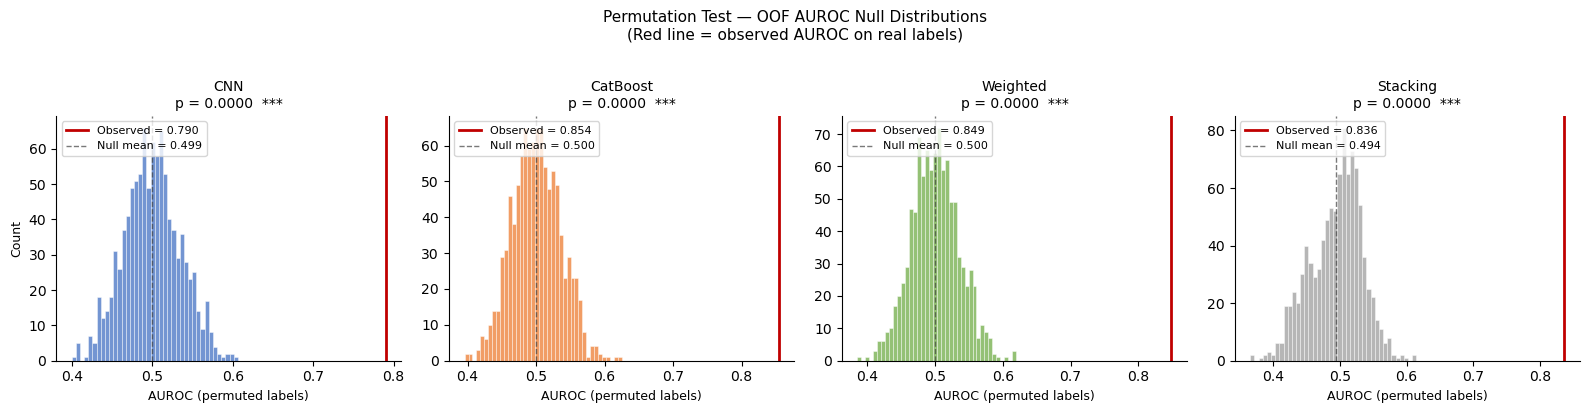


--- Interpretation ---
CNN         : p=0.0000 — Real signal confirmed. Observed AUROC 0.790 is 0.291 above null mean. Performance drop on independent set is not explained by overfitting alone.
CatBoost    : p=0.0000 — Real signal confirmed. Observed AUROC 0.854 is 0.354 above null mean. Performance drop on independent set is not explained by overfitting alone.
Weighted    : p=0.0000 — Real signal confirmed. Observed AUROC 0.849 is 0.349 above null mean. Performance drop on independent set is not explained by overfitting alone.
Stacking    : p=0.0000 — Real signal confirmed. Observed AUROC 0.836 is 0.342 above null mean. Performance drop on independent set is not explained by overfitting alone.


In [15]:
# ── Self-contained permutation test ──────────────────────────────────────
# Reads oof_probs.tsv written by main() in Cell 10.
# Cell 10 must have finished running (look for '[DONE] saved -> oof_probs.tsv').

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, recall_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

OOF_TSV        = 'oof_probs.tsv'
N_PERMUTATIONS = 1000
SEED_PERM      = 42
N_SPLITS_PERM  = 5

assert os.path.exists(OOF_TSV), (
    f"'{OOF_TSV}' not found. "
    "Check that Cell 10 printed '[DONE] saved -> oof_probs.tsv' before running this cell.")

# ── Load ─────────────────────────────────────────────────────────────────
oof       = pd.read_csv(OOF_TSV, sep='\t')
y         = oof['y'].values.astype(int)
p_cnn_oof = oof['p_cnn'].values.astype(float)
p_cb_oof  = oof['p_catboost'].values.astype(float)
N         = len(y)
print(f'[INFO] Loaded {N} samples  pos={y.sum()}  neg={(y==0).sum()}')

# ── Re-derive best_w ─────────────────────────────────────────────────────
W_GRID   = np.linspace(0, 1, 21)
skf_perm = StratifiedKFold(n_splits=N_SPLITS_PERM, shuffle=True, random_state=SEED_PERM)

def _thr(y_true, p, min_rec=0.85):
    thrs = np.unique(np.quantile(p, np.linspace(0, 1, 201)))
    best = None
    for t in thrs:
        yh = (p >= t).astype(int)
        r  = recall_score(y_true, yh, zero_division=0)
        if r < min_rec: continue
        pr = precision_score(y_true, yh, zero_division=0)
        if best is None or pr > best[0]: best = (pr, r, float(t))
    return best[2] if best else 0.5

best_w, best_score = 0.5, -1.0
for w in W_GRID:
    scores = []
    for tr, va in skf_perm.split(np.zeros(N), y):
        thr = _thr(y[tr], w*p_cnn_oof[tr]+(1-w)*p_cb_oof[tr])
        yh  = (w*p_cnn_oof[va]+(1-w)*p_cb_oof[va] >= thr).astype(int)
        scores.append(recall_score(y[va], yh, zero_division=0) +
                      0.2*precision_score(y[va], yh, zero_division=0))
    if np.mean(scores) > best_score:
        best_score, best_w = np.mean(scores), w
print(f'[INFO] best_w = {best_w:.2f}')

# ── Observed AUROC on real labels ─────────────────────────────────────────
p_w = best_w*p_cnn_oof + (1-best_w)*p_cb_oof
meta = np.vstack([p_cnn_oof, p_cb_oof]).T
p_s = np.zeros(N)
for tr, va in skf_perm.split(meta, y):
    lr = LogisticRegression(solver='liblinear', max_iter=500)
    lr.fit(meta[tr], y[tr])
    p_s[va] = lr.predict_proba(meta[va])[:, 1]

observed = {
    'CNN':      roc_auc_score(y, p_cnn_oof),
    'CatBoost': roc_auc_score(y, p_cb_oof),
    'Weighted': roc_auc_score(y, p_w),
    'Stacking': roc_auc_score(y, p_s),
}
print('\nObserved OOF AUROC:')
for k, v in observed.items(): print(f'  {k:12s}: {v:.4f}')

# ── Null distributions ────────────────────────────────────────────────────
rng  = np.random.default_rng(SEED_PERM)
null = {k: np.zeros(N_PERMUTATIONS) for k in observed}

print(f'\nRunning {N_PERMUTATIONS} permutations...')
for i in range(N_PERMUTATIONS):
    yp = rng.permutation(y)
    null['CNN'][i]      = roc_auc_score(yp, p_cnn_oof)
    null['CatBoost'][i] = roc_auc_score(yp, p_cb_oof)
    null['Weighted'][i] = roc_auc_score(yp, p_w)
    ps_perm = np.zeros(N)
    for tr, va in skf_perm.split(meta, yp):
        lr = LogisticRegression(solver='liblinear', max_iter=500)
        lr.fit(meta[tr], yp[tr])
        ps_perm[va] = lr.predict_proba(meta[va])[:, 1]
    null['Stacking'][i] = roc_auc_score(yp, ps_perm)
    if (i+1) % 200 == 0: print(f'  {i+1}/{N_PERMUTATIONS} done')

# ── p-values & summary ────────────────────────────────────────────────────
pvalues = {k: float((null[k] >= observed[k]).mean()) for k in observed}

print('\n' + '='*58)
print('PERMUTATION TEST RESULTS')
print('='*58)
print(f'{"Model":12s}  {"Observed":>8s}  {"Null mean":>9s}  {"Null std":>8s}  {"p-value":>8s}  Sig')
print('-'*58)
rows = []
for k in ['CNN', 'CatBoost', 'Weighted', 'Stacking']:
    obs  = observed[k]; nm = null[k].mean(); ns = null[k].std(); pv = pvalues[k]
    sig  = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'n.s.'))
    print(f'{k:12s}  {obs:8.4f}  {nm:9.4f}  {ns:8.4f}  {pv:8.4f}  {sig}')
    rows.append({'model':k,'observed_auroc':obs,'null_mean':nm,'null_std':ns,'p_value':pv,'significance':sig})
print('='*58)
print('*** p<0.001  ** p<0.01  * p<0.05  n.s. not significant')

pd.DataFrame(rows).to_csv('permutation_test_results.csv', index=False)
print('\n[SAVED] permutation_test_results.csv')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(
    'Permutation Test — OOF AUROC Null Distributions\n'
    '(Red line = observed AUROC on real labels)',
    fontsize=11, y=1.02)
colors = ['#4472C4', '#ED7D31', '#70AD47', '#9E9E9E']
for ax, k, col in zip(axes, ['CNN','CatBoost','Weighted','Stacking'], colors):
    ax.hist(null[k], bins=40, color=col, alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.axvline(observed[k], color='#C00000', linewidth=2.0,
               label=f'Observed = {observed[k]:.3f}')
    ax.axvline(null[k].mean(), color='#404040', linewidth=1.0, linestyle='--', alpha=0.7,
               label=f'Null mean = {null[k].mean():.3f}')
    pv  = pvalues[k]
    sig = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'n.s.'))
    ax.set_title(f'{k}\np = {pv:.4f}  {sig}', fontsize=10)
    ax.set_xlabel('AUROC (permuted labels)', fontsize=9)
    ax.set_ylabel('Count' if ax is axes[0] else '', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interpretation ────────────────────────────────────────────────────────
print('\n--- Interpretation ---')
for k in ['CNN', 'CatBoost', 'Weighted', 'Stacking']:
    pv  = pvalues[k]; obs = observed[k]; gap = obs - null[k].mean()
    if pv < 0.05:
        print(f'{k:12s}: p={pv:.4f} — Real signal confirmed. '
              f'Observed AUROC {obs:.3f} is {gap:.3f} above null mean. '
              f'Performance drop on independent set is not explained by overfitting alone.')
    else:
        print(f'{k:12s}: p={pv:.4f} — Cannot rule out overfitting. '
              f'Observed AUROC {obs:.3f} is not significantly above null distribution.')


#### 13. Maximum Mean Discrepancy (MMD) — Multivariate Domain Shift Test

##### While the KS test measures shift in each feature independently (univariate),
##### MMD measures whether the **joint** distribution of all features differs between
##### training and independent sets — capturing correlational structure that KS misses.

##### **How it works:**
##### MMD computes the distance between the mean embeddings of two distributions
##### in a Reproducing Kernel Hilbert Space (RKHS) using an RBF kernel.
##### A permutation test then asks: if both samples came from the same distribution,
##### how often would we see an MMD value this large by chance?

##### **Outputs:**
##### 1. MMD² statistic and p-value for full feature set vs stable feature subset (27 features)
##### 2. Per-feature-group MMD breakdown (loudness, spectral, jitter/shimmer, formant, etc.)
##### 3. Comparison plot: KS shift (univariate) vs MMD contribution (multivariate)


[INFO] Loading training static features...
       N=252  pos=208  neg=296  features=131
[INFO] Loading independent static features...
       N=81

[INFO] Running MMD permutation tests (n_perm=1000)...


  Full features  (131 dims):  MMD²=0.604771  p=0.0000  ***
  Stable features( 27 dims):  MMD²=0.010148  p=0.0040  **
  MMD² reduction: 98.3% by using stable features only

[INFO] Computing per-group MMD...
  Loudness/Energy      ( 15 feats):  MMD²=0.705772  p=0.0000  ***
  Spectral             ( 41 feats):  MMD²=0.202445  p=0.0000  ***
  F0/Pitch             ( 22 feats):  MMD²=0.090678  p=0.0000  ***
  Jitter/Shimmer       ( 15 feats):  MMD²=0.004396  p=0.0000  ***


/tmp/ipykernel_1477408/279709147.py:41: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'Formant':          lambda c: c.str.contains('F[123](freq|band|amp|frequency|bandwidth)|f[123]_loc|b[123]_loc', case=False, regex=True),


  Formant              ( 26 feats):  MMD²=0.093260  p=0.0000  ***
  HNR                  (  4 feats):  MMD²=0.002033  p=0.0000  ***
  Temporal/Voice       ( 10 feats):  MMD²=0.074424  p=0.0000  ***
  CPP                  (  2 feats):  MMD²=0.039762  p=0.0000  ***


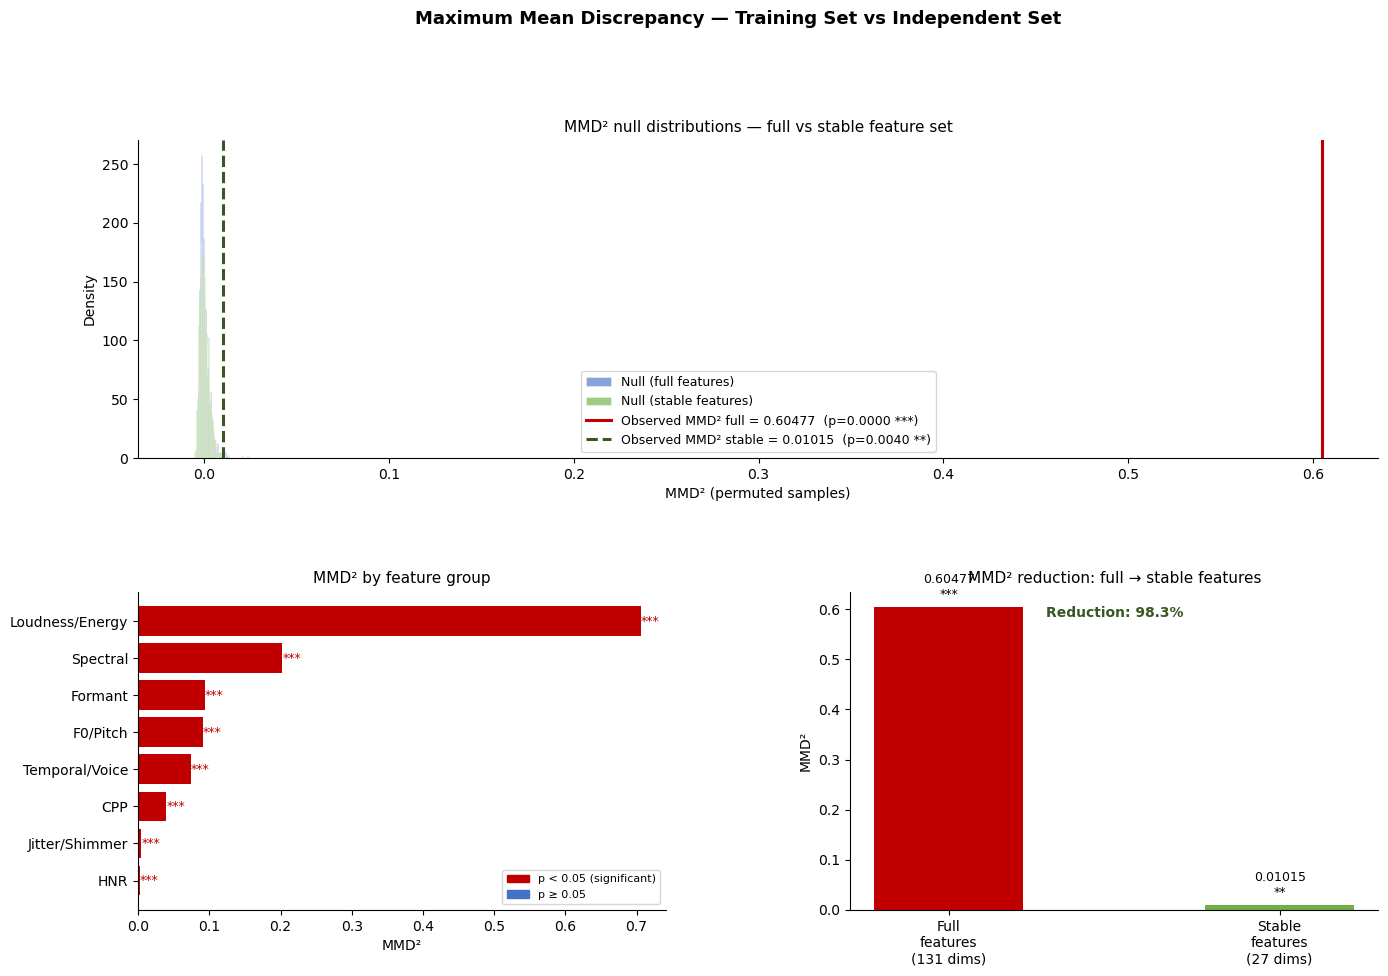


MMD ANALYSIS SUMMARY
  Full features  (131 dims):  MMD²=0.604771  p=0.0000  ***
  Stable features( 27 dims):  MMD²=0.010148  p=0.0040  **
  MMD² reduction: 98.3% (justifies Strategy 1 feature selection)

Per-group breakdown:
          group  n_features     mmd2  p_value significance
Loudness/Energy          15 0.705772      0.0          ***
       Spectral          41 0.202445      0.0          ***
        Formant          26 0.093260      0.0          ***
       F0/Pitch          22 0.090678      0.0          ***
 Temporal/Voice          10 0.074424      0.0          ***
            CPP           2 0.039762      0.0          ***
 Jitter/Shimmer          15 0.004396      0.0          ***
            HNR           4 0.002033      0.0          ***

[SAVED] mmd_global.csv  mmd_groups.csv  mmd_analysis.png

--- Interpretation ---
Full features: MMD² significantly > 0 (p=0.0000) — multivariate distribution shift confirmed beyond univariate KS results.
Stable features: MMD² reduced by 98.3%

In [2]:
# ── Self-contained MMD analysis ──────────────────────────────────────────
# Loads training and independent static features directly from TSV files.
# Requires: CONTROL_STATIC_TSV, PATIENT_STATIC_TSV defined in Cell 10,
#           and the independent static features TSV path set below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── Path to independent set static features — edit if needed ─────────────
# ── Edit paths if different from Cell 10 defaults ───────────────────────
CONTROL_STATIC_TSV = "/home/taor/work/bridge2AI-data/Gituploading/dataset/control_data/vowel_task_data/static_control_prolonged-vowel.tsv"
PATIENT_STATIC_TSV = "/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/static_parkinson_prolonged-vowel.tsv"
INDEP_STATIC_TSV   = '/home/taor/work/bridge2AI-data/independen_test_data/features/static_features.tsv'

# 27 stable features identified by KS shift < 0.2
STABLE_FEATURES = [
    'shimmerLocaldB_sma3nz_amean', 'F1frequency_sma3nz_stddevNorm',
    'VoicedSegmentsPerSec', 'F2bandwidth_sma3nz_stddevNorm',
    'F2frequency_sma3nz_stddevNorm', 'logRelF0-H1-A3_sma3nz_stddevNorm',
    'hammarbergIndexV_sma3nz_stddevNorm', 'F1bandwidth_sma3nz_stddevNorm',
    'F1bandwidth_sma3nz_amean', 'apq11_shimmer', 'F3bandwidth_sma3nz_stddevNorm',
    'local_shimmer', 'localDB_shimmer', 'alphaRatioV_sma3nz_stddevNorm',
    'F3frequency_sma3nz_stddevNorm', 'F2bandwidth_sma3nz_amean', 'std_hnr_db',
    'HNRdBACF_sma3nz_amean', 'hammarbergIndexV_sma3nz_amean',
    'F2frequency_sma3nz_amean', 'F3frequency_sma3nz_amean',
    'F3bandwidth_sma3nz_amean', 'spectral_std_dev', 'F1frequency_sma3nz_amean',
    'spectralFluxV_sma3nz_stddevNorm', 'slopeV500-1500_sma3nz_amean',
    'loudness_sma3_pctlrange0-2',
]

# Feature groups for breakdown analysis
FEATURE_GROUPS = {
    'Loudness/Energy':  lambda c: c.str.contains('loudness|equivalentSound|intensity|range_ratio', case=False, regex=True),
    'Spectral':         lambda c: c.str.contains('spectral|slope|mfcc', case=False, regex=True),
    'F0/Pitch':         lambda c: c.str.contains('F0semitone|F0|f0_hertz|std_f0', case=False, regex=True),
    'Jitter/Shimmer':   lambda c: c.str.contains('jitter|shimmer', case=False, regex=True),
    'Formant':          lambda c: c.str.contains('F[123](freq|band|amp|frequency|bandwidth)|f[123]_loc|b[123]_loc', case=False, regex=True),
    'HNR':              lambda c: c.str.contains('HNR|hnr', case=False, regex=True),
    'Temporal/Voice':   lambda c: c.str.contains('duration|speaking|phonation|pause|Voiced|Unvoiced', case=False, regex=True),
    'CPP':              lambda c: c.str.contains('cepstral', case=False, regex=True),
}


# ══════════════════════════════════════════════════════════════════════════
# Core MMD functions
# ══════════════════════════════════════════════════════════════════════════

def rbf_kernel_matrix(X, Y, sigma):
    """
    Compute RBF kernel matrix K(X, Y) = exp(-||x_i - y_j||^2 / (2*sigma^2)).
    Uses the identity ||x-y||^2 = ||x||^2 + ||y||^2 - 2<x,y> for efficiency.
    """
    XX = np.sum(X**2, axis=1, keepdims=True)   # (n, 1)
    YY = np.sum(Y**2, axis=1, keepdims=True)   # (m, 1)
    XY = X @ Y.T                               # (n, m)
    sq_dists = XX + YY.T - 2 * XY              # (n, m)
    sq_dists = np.maximum(sq_dists, 0)         # numerical safety
    return np.exp(-sq_dists / (2 * sigma**2))


def mmd_squared(X, Y, sigma=None):
    """
    Unbiased estimator of MMD².

    MMD²(X,Y) = E[k(x,x')] - 2*E[k(x,y)] + E[k(y,y')]

    Uses median heuristic for bandwidth if sigma is not provided:
      sigma = median(pairwise distances in pooled sample) / sqrt(2)

    Parameters
    ----------
    X : (n, d) array  — source samples (training set)
    Y : (m, d) array  — target samples (independent set)
    sigma : float or None

    Returns
    -------
    mmd2 : float
    sigma : float  (the bandwidth actually used)
    """
    if sigma is None:
        # Median heuristic on a subsample to keep cost manageable
        n_sub = min(300, len(X), len(Y))
        rng   = np.random.default_rng(42)
        Xs = X[rng.choice(len(X), n_sub, replace=False)]
        Ys = Y[rng.choice(len(Y), n_sub, replace=False)]
        Z  = np.vstack([Xs, Ys])
        ZZ = np.sum(Z**2, axis=1, keepdims=True)
        sq = np.maximum(ZZ + ZZ.T - 2 * Z @ Z.T, 0)
        sigma = float(np.sqrt(np.median(sq[sq > 0]) / 2))
        sigma = max(sigma, 1e-6)

    n, m = len(X), len(Y)
    Kxx = rbf_kernel_matrix(X, X, sigma)
    Kyy = rbf_kernel_matrix(Y, Y, sigma)
    Kxy = rbf_kernel_matrix(X, Y, sigma)

    # Unbiased: zero out diagonal of Kxx and Kyy
    np.fill_diagonal(Kxx, 0)
    np.fill_diagonal(Kyy, 0)

    mmd2 = (Kxx.sum() / (n*(n-1))
            + Kyy.sum() / (m*(m-1))
            - 2 * Kxy.mean())
    return float(mmd2), sigma


def mmd_permutation_test(X, Y, n_perm=1000, sigma=None, seed=42):
    """
    Permutation test for MMD².
    Under H0, both samples come from the same distribution —
    pooling and randomly re-splitting should give similar MMD² values.

    Returns
    -------
    observed_mmd2 : float
    p_value       : float  (fraction of permutations >= observed)
    null_dist     : (n_perm,) array
    sigma         : float  (bandwidth used)
    """
    observed_mmd2, sigma = mmd_squared(X, Y, sigma=sigma)
    n, m  = len(X), len(Y)
    Z     = np.vstack([X, Y])
    rng   = np.random.default_rng(seed)
    null  = np.zeros(n_perm)

    for i in range(n_perm):
        idx  = rng.permutation(n + m)
        Xp   = Z[idx[:n]]
        Yp   = Z[idx[n:]]
        null[i], _ = mmd_squared(Xp, Yp, sigma=sigma)

    p_value = float((null >= observed_mmd2).mean())
    return observed_mmd2, p_value, null, sigma


# ══════════════════════════════════════════════════════════════════════════
# Data loading
# ══════════════════════════════════════════════════════════════════════════

def load_static_from_tsv(tsv_path, task='prolonged-vowel', label_col=None):
    """Generic loader: reads a static feature TSV, filters by task, returns X and feat_cols."""
    df = pd.read_csv(tsv_path, sep='\t', dtype=str)
    if 'task_name' in df.columns:
        df = df[df['task_name'].astype(str).str.strip() == task].copy()
    df = df.drop_duplicates('participant_id')
    base_drop = {'participant_id', 'session_id', 'task_name', 'transcription', 'label'}
    if label_col:
        base_drop.discard(label_col)
    feat_cols = [c for c in df.columns if c not in base_drop]
    X = df.set_index('participant_id')[feat_cols]
    y = df.set_index('participant_id')[label_col].astype(int).values if label_col and label_col in df.columns else None
    return X, y, feat_cols, df['participant_id'].tolist()


def load_train_static(ctrl_tsv, pat_tsv, task='prolonged-vowel', drop_cols=None):
    """Load and concatenate control + patient static features from separate TSVs."""
    c = pd.read_csv(ctrl_tsv, sep='\t', dtype=str); c['label'] = 0
    p = pd.read_csv(pat_tsv,  sep='\t', dtype=str); p['label'] = 1
    # Compute common cols BEFORE adding label to avoid including it in common check
    common_raw = sorted(set(c.columns) & set(p.columns))
    df = pd.concat([c[common_raw + ['label']], p[common_raw + ['label']]], ignore_index=True)
    if 'task_name' in df.columns:
        df = df[df['task_name'].astype(str).str.strip() == task].copy()
    df = df.drop_duplicates('participant_id')
    base_drop = {'participant_id', 'session_id', 'task_name', 'transcription', 'label'}
    if drop_cols:
        base_drop |= set(drop_cols)
    feat_cols = [c for c in df.columns if c not in base_drop]
    if len(feat_cols) == 0:
        # Fallback: use all non-ID columns as features
        # This happens when ctrl/pat TSVs only have ID columns
        # Try loading from the independent TSV structure as reference
        raise ValueError(
            f"load_train_static: feat_cols is empty after filtering.\n"
            f"  ctrl_tsv columns: {list(pd.read_csv(ctrl_tsv, sep='\t', nrows=0).columns)}\n"
            f"  Ensure CONTROL_STATIC_TSV and PATIENT_STATIC_TSV point to files "
            f"with acoustic feature columns, not just ID columns.")
    X = df[feat_cols]
    y = df['label'].astype(int).values
    print(f'       N={len(y)}  pos={y.sum()}  neg={(y==0).sum()}  features={len(feat_cols)}')
    return X, y, feat_cols


def load_indep_static(tsv, feat_cols, task='prolonged-vowel'):
    """Load independent set static features, aligned to training feat_cols."""
    df = pd.read_csv(tsv, sep='\t', dtype=str)
    if 'task_name' in df.columns:
        df = df[df['task_name'].astype(str).str.strip() == task].copy()
    df = df.drop_duplicates('participant_id')
    X = df.reindex(columns=feat_cols)
    return X


def preprocess(X_tr, X_te):
    """Convert to float64 numpy arrays, impute (median), then StandardScale."""
    def to_float_array(df):
        return df.apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float64, na_value=np.nan)

    Xtr_np = to_float_array(X_tr).copy()   # .copy() ensures array is writable
    Xte_np = to_float_array(X_te).copy()

    # Fill all-NaN columns with 0 before imputing
    all_nan_tr = np.where(np.all(np.isnan(Xtr_np), axis=0))[0]
    all_nan_te = np.where(np.all(np.isnan(Xte_np), axis=0))[0]
    Xtr_np[:, all_nan_tr] = 0.0
    Xte_np[:, all_nan_te] = 0.0

    imp     = SimpleImputer(strategy='median')
    X_tr_imp = imp.fit_transform(Xtr_np)
    X_te_imp = imp.transform(Xte_np)

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_imp)
    X_te_sc = scaler.transform(X_te_imp)
    return X_tr_sc, X_te_sc


# ── Load data ─────────────────────────────────────────────────────────────
print('[INFO] Loading training static features...')
X_tr_raw, y_tr, feat_cols = load_train_static(
    CONTROL_STATIC_TSV, PATIENT_STATIC_TSV)

print('[INFO] Loading independent static features...')
X_te_raw = load_indep_static(INDEP_STATIC_TSV, feat_cols)
print(f'       N={len(X_te_raw)}')

X_tr_sc, X_te_sc = preprocess(X_tr_raw.copy(), X_te_raw.copy())
feat_cols_arr = np.array(feat_cols)


# ══════════════════════════════════════════════════════════════════════════
# 1. Global MMD: full features vs stable-feature subset
# ══════════════════════════════════════════════════════════════════════════

N_PERM = 1000
print(f'\n[INFO] Running MMD permutation tests (n_perm={N_PERM})...')

# Full feature set
mmd2_full, pval_full, null_full, sigma_full = mmd_permutation_test(
    X_tr_sc, X_te_sc, n_perm=N_PERM)
sig_full = '***' if pval_full<0.001 else ('**' if pval_full<0.01 else ('*' if pval_full<0.05 else 'n.s.'))
print(f'  Full features  ({len(feat_cols):3d} dims):  MMD²={mmd2_full:.6f}  p={pval_full:.4f}  {sig_full}')

# Stable feature subset
stable_idx = [i for i, c in enumerate(feat_cols) if c in STABLE_FEATURES]
mmd2_stab, pval_stab, null_stab, sigma_stab = mmd_permutation_test(
    X_tr_sc[:, stable_idx], X_te_sc[:, stable_idx], n_perm=N_PERM)
sig_stab = '***' if pval_stab<0.001 else ('**' if pval_stab<0.01 else ('*' if pval_stab<0.05 else 'n.s.'))
print(f'  Stable features({len(stable_idx):3d} dims):  MMD²={mmd2_stab:.6f}  p={pval_stab:.4f}  {sig_stab}')
print(f'  MMD² reduction: {(1 - mmd2_stab/mmd2_full)*100:.1f}% by using stable features only')


# ══════════════════════════════════════════════════════════════════════════
# 2. Per-group MMD breakdown
# ══════════════════════════════════════════════════════════════════════════

print('\n[INFO] Computing per-group MMD...')
feat_series = pd.Series(feat_cols)
group_results = []

for group_name, selector in FEATURE_GROUPS.items():
    mask = selector(feat_series)
    idxs = [i for i, m in enumerate(mask) if m]
    if len(idxs) < 2:
        continue
    mmd2_g, pval_g, _, _ = mmd_permutation_test(
        X_tr_sc[:, idxs], X_te_sc[:, idxs],
        n_perm=500, sigma=sigma_full)   # reuse sigma for comparability
    sig_g = '***' if pval_g<0.001 else ('**' if pval_g<0.01 else ('*' if pval_g<0.05 else 'n.s.'))
    group_results.append({
        'group': group_name, 'n_features': len(idxs),
        'mmd2': mmd2_g, 'p_value': pval_g, 'significance': sig_g
    })
    print(f'  {group_name:20s} ({len(idxs):3d} feats):  MMD²={mmd2_g:.6f}  p={pval_g:.4f}  {sig_g}')

df_groups = pd.DataFrame(group_results).sort_values('mmd2', ascending=False)


# ══════════════════════════════════════════════════════════════════════════
# 3. Visualisation
# ══════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── Panel A: Global MMD null distributions ────────────────────────────────
ax_a = fig.add_subplot(gs[0, :])
ax_a.hist(null_full, bins=50, color='#4472C4', alpha=0.65, label='Null (full features)',
          edgecolor='white', linewidth=0.4, density=True)
ax_a.hist(null_stab, bins=50, color='#70AD47', alpha=0.65, label='Null (stable features)',
          edgecolor='white', linewidth=0.4, density=True)
ax_a.axvline(mmd2_full, color='#C00000', linewidth=2.2, linestyle='-',
             label=f'Observed MMD² full = {mmd2_full:.5f}  (p={pval_full:.4f} {sig_full})')
ax_a.axvline(mmd2_stab, color='#385723', linewidth=2.2, linestyle='--',
             label=f'Observed MMD² stable = {mmd2_stab:.5f}  (p={pval_stab:.4f} {sig_stab})')
ax_a.set_xlabel('MMD² (permuted samples)', fontsize=10)
ax_a.set_ylabel('Density', fontsize=10)
ax_a.set_title('MMD² null distributions — full vs stable feature set', fontsize=11)
ax_a.legend(fontsize=9)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# ── Panel B: Per-group MMD bar chart ──────────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
colors_b = ['#C00000' if p < 0.05 else '#4472C4' for p in df_groups['p_value']]
bars = ax_b.barh(df_groups['group'], df_groups['mmd2'], color=colors_b)
for bar, row in zip(bars, df_groups.itertuples()):
    ax_b.text(bar.get_width() + 0.000002, bar.get_y() + bar.get_height()/2,
              f'{row.significance}', va='center', fontsize=9,
              color='#C00000' if row.p_value < 0.05 else '#4472C4')
ax_b.set_xlabel('MMD²', fontsize=10)
ax_b.set_title('MMD² by feature group', fontsize=11)
ax_b.invert_yaxis()
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
from matplotlib.patches import Patch
ax_b.legend(handles=[
    Patch(color='#C00000', label='p < 0.05 (significant)'),
    Patch(color='#4472C4', label='p ≥ 0.05'),
], fontsize=8, loc='lower right')

# ── Panel C: Full vs stable MMD² summary bar ──────────────────────────────
ax_c = fig.add_subplot(gs[1, 1])
labels_c = ['Full\nfeatures\n(131 dims)', f'Stable\nfeatures\n({len(stable_idx)} dims)']
vals_c   = [mmd2_full, mmd2_stab]
pvals_c  = [pval_full, pval_stab]
colors_c = ['#C00000', '#70AD47']
b2 = ax_c.bar(labels_c, vals_c, color=colors_c, width=0.45)
for bar, val, pv in zip(b2, vals_c, pvals_c):
    sig = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'n.s.'))
    ax_c.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + max(vals_c)*0.02,
              f'{val:.5f}\n{sig}', ha='center', va='bottom', fontsize=9)
ax_c.set_ylabel('MMD²', fontsize=10)
ax_c.set_title('MMD² reduction: full → stable features', fontsize=11)
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
reduction_pct = (1 - mmd2_stab/mmd2_full) * 100
ax_c.text(0.5, 0.92, f'Reduction: {reduction_pct:.1f}%',
          transform=ax_c.transAxes, ha='center', fontsize=10,
          color='#385723', fontweight='bold')

plt.suptitle('Maximum Mean Discrepancy — Training Set vs Independent Set',
             fontsize=13, y=1.01, fontweight='bold')
plt.savefig('mmd_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════
# 4. Summary table
# ══════════════════════════════════════════════════════════════════════════

print('\n' + '='*62)
print('MMD ANALYSIS SUMMARY')
print('='*62)
print(f'  Full features  ({len(feat_cols):3d} dims):  '
      f'MMD²={mmd2_full:.6f}  p={pval_full:.4f}  {sig_full}')
print(f'  Stable features({len(stable_idx):3d} dims):  '
      f'MMD²={mmd2_stab:.6f}  p={pval_stab:.4f}  {sig_stab}')
print(f'  MMD² reduction: {reduction_pct:.1f}% (justifies Strategy 1 feature selection)')
print('\nPer-group breakdown:')
print(df_groups[['group','n_features','mmd2','p_value','significance']].to_string(index=False))

# Save
summary_global = pd.DataFrame([
    {'scope': 'full_features',   'n_dims': len(feat_cols),   'mmd2': mmd2_full,
     'p_value': pval_full,  'significance': sig_full,  'sigma': sigma_full},
    {'scope': 'stable_features', 'n_dims': len(stable_idx),  'mmd2': mmd2_stab,
     'p_value': pval_stab, 'significance': sig_stab, 'sigma': sigma_stab},
])
summary_global.to_csv('mmd_global.csv', index=False)
df_groups.to_csv('mmd_groups.csv', index=False)
print('\n[SAVED] mmd_global.csv  mmd_groups.csv  mmd_analysis.png')

print('\n--- Interpretation ---')
if pval_full < 0.05:
    print(f'Full features: MMD² significantly > 0 (p={pval_full:.4f}) — '
          'multivariate distribution shift confirmed beyond univariate KS results.')
else:
    print(f'Full features: MMD² not significant (p={pval_full:.4f}) — '
          'multivariate shift not detected at this sample size.')
if pval_stab < pval_full:
    print(f'Stable features: lower p-value reduction ({pval_stab:.4f} vs {pval_full:.4f}) — '
          'stable subset still shows some shift; consider further feature screening.')
elif mmd2_stab < mmd2_full * 0.5:
    print(f'Stable features: MMD² reduced by {reduction_pct:.1f}% — '
          'KS-based feature selection effectively reduces multivariate shift.')


[INFO] Loading static features...
       N=252  pos=104  neg=148  features=130
[INFO] Training CatBoost on full dataset for SHAP...


[INFO] Done.
[INFO] Computing SHAP values...


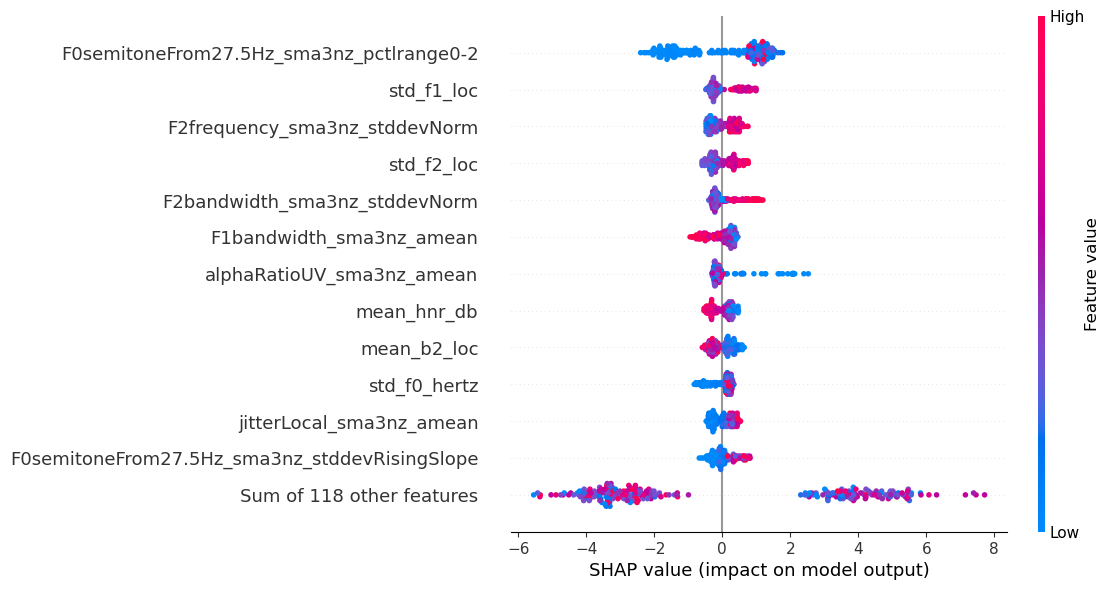

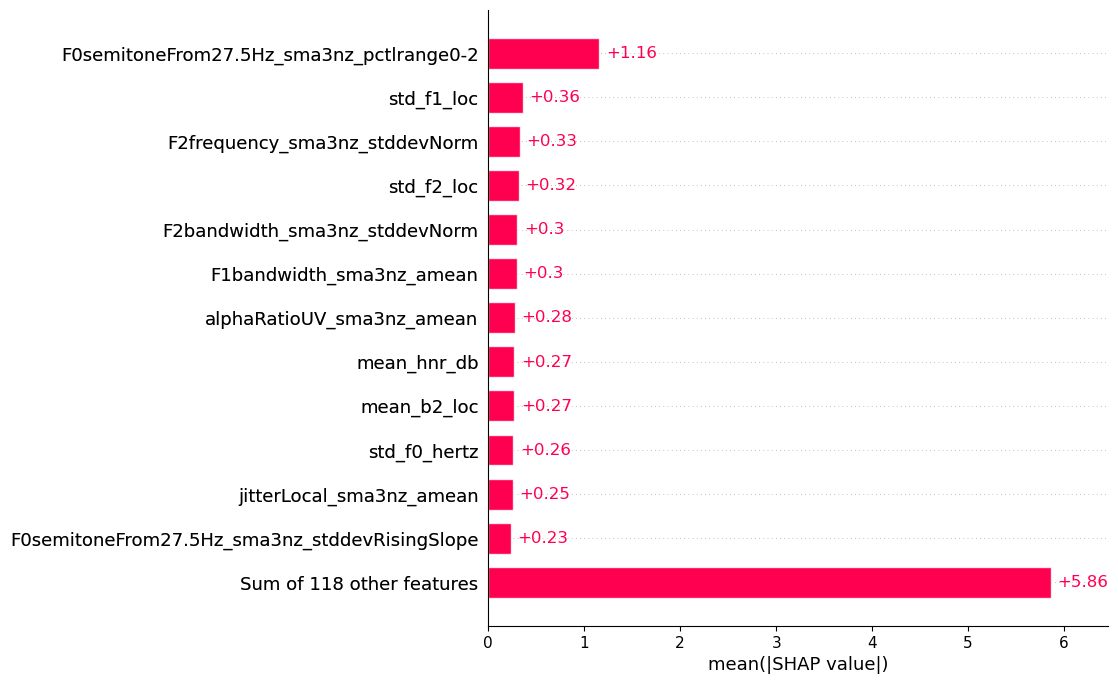

In [26]:
# ── SHAP analysis for CatBoost — self-contained ──────────────────────────
# Retrains CatBoost on the full training set to get a single model for SHAP.
# Cell 10 (main()) must have run first so that:
#   CONTROL_STATIC_TSV, PATIENT_STATIC_TSV, SEED, TASK are defined.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
import shap

# ── Config ────────────────────────────────────────────────────────────────
TOP_N        = 20          # number of features to show
N_SHAP_SAMPLES = None      # None = use all samples; set e.g. 100 for speed
CONTROL_STATIC_TSV = "/home/taor/work/bridge2AI-data/Gituploading/dataset/control_data/vowel_task_data/static_control_prolonged-vowel.tsv"
PATIENT_STATIC_TSV = "/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/static_parkinson_prolonged-vowel.tsv"
# ── Load static features ─────────────────────────────────────────────────
def _load_static(ctrl_tsv, pat_tsv, task='prolonged-vowel'):
    c = pd.read_csv(ctrl_tsv, sep='\t', dtype=str)
    p = pd.read_csv(pat_tsv,  sep='\t', dtype=str)
    # Compute common cols BEFORE adding label to avoid duplication
    common_raw = sorted(set(c.columns) & set(p.columns))
    c['label'] = 0
    p['label'] = 1
    df = pd.concat([c[common_raw + ['label']], p[common_raw + ['label']]], ignore_index=True)
    if 'task_name' in df.columns:
        df = df[df['task_name'].astype(str).str.strip() == task].copy()
    df = df.drop_duplicates('participant_id')
    drop = {'participant_id','session_id','task_name','transcription','label', 'duration'}
    feat_cols = [col for col in df.columns if col not in drop]
    X = df[feat_cols].apply(pd.to_numeric, errors='coerce')
    y = df['label'].astype(int).values.ravel()
    assert X.shape[0] == len(y), f'Shape mismatch: X={X.shape}, y={len(y)}'
    return X, y, feat_cols

print('[INFO] Loading static features...')
X_shap, y_shap, feat_cols_shap = _load_static(CONTROL_STATIC_TSV, PATIENT_STATIC_TSV)
print(f'       N={len(y_shap)}  pos={y_shap.sum()}  neg={(y_shap==0).sum()}  features={len(feat_cols_shap)}')

# ── Impute + scale ────────────────────────────────────────────────────────
Xnp = X_shap.to_numpy(dtype=np.float64, na_value=np.nan).copy()
all_nan_cols = np.where(np.all(np.isnan(Xnp), axis=0))[0]
Xnp[:, all_nan_cols] = 0.0
imp = SimpleImputer(strategy='median')
Xnp = imp.fit_transform(Xnp)
# Keep as DataFrame with feature names for SHAP
X_df = pd.DataFrame(Xnp, columns=feat_cols_shap)
y_shap = np.array(y_shap).ravel().astype(int)   # ensure 1-D int array

# ── Train CatBoost on full dataset ────────────────────────────────────────
print('[INFO] Training CatBoost on full dataset for SHAP...')
cb_full = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    random_seed=42,
    verbose=False,
)
cb_full.fit(X_df, y_shap)
print('[INFO] Done.')

# ── SHAP values ───────────────────────────────────────────────────────────
print('[INFO] Computing SHAP values...')
X_shap_input = X_df if N_SHAP_SAMPLES is None else X_df.sample(N_SHAP_SAMPLES, random_state=SEED)
explainer   = shap.Explainer(cb_full)
shap_values = explainer(X_shap_input)
plt.figure()
shap.plots.beeswarm(shap_values,show=False, max_display=13)
fig.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.figure()
shap.plots.bar(shap_values.abs.mean(0),show=False, max_display=13)
plt.savefig('shap_bar.png', dpi=150,bbox_inches='tight')



# # CatBoost TreeExplainer returns (N, F) for binary; use directly
# if isinstance(shap_values, list):
#     shap_values = shap_values[1]   # class 1 (PD)
# print(f'[INFO] SHAP matrix shape: {shap_values.shape}')

# # ── Mark stable features (KS < 0.2) for colour coding only ──────────────
# # All features are included in the SHAP analysis.
# # Stable features are highlighted in green to show which are domain-robust.
# STABLE_FEATURES = [
#     'shimmerLocaldB_sma3nz_amean', 'F1frequency_sma3nz_stddevNorm',
#     'VoicedSegmentsPerSec', 'F2bandwidth_sma3nz_stddevNorm',
#     'F2frequency_sma3nz_stddevNorm', 'logRelF0-H1-A3_sma3nz_stddevNorm',
#     'hammarbergIndexV_sma3nz_stddevNorm', 'F1bandwidth_sma3nz_stddevNorm',
#     'F1bandwidth_sma3nz_amean', 'apq11_shimmer', 'F3bandwidth_sma3nz_stddevNorm',
#     'local_shimmer', 'localDB_shimmer', 'alphaRatioV_sma3nz_stddevNorm',
#     'F3frequency_sma3nz_stddevNorm', 'F2bandwidth_sma3nz_amean', 'std_hnr_db',
#     'HNRdBACF_sma3nz_amean', 'hammarbergIndexV_sma3nz_amean',
#     'F2frequency_sma3nz_amean', 'F3frequency_sma3nz_amean',
#     'F3bandwidth_sma3nz_amean', 'spectral_std_dev', 'F1frequency_sma3nz_amean',
#     'spectralFluxV_sma3nz_stddevNorm', 'slopeV500-1500_sma3nz_amean',
#     'loudness_sma3_pctlrange0-2',
# ]

# feature_names = list(X_shap_input.columns)   # all features
# is_stable = np.array([f in STABLE_FEATURES for f in feature_names])

# # ── Mean |SHAP| ranking ───────────────────────────────────────────────────
# mean_abs_shap = np.abs(shap_values).mean(axis=0)
# ranked_idx    = np.argsort(mean_abs_shap)[::-1]
# top_idx       = ranked_idx[:TOP_N]
# top_names     = [feature_names[i] for i in top_idx]
# top_stable    = [is_stable[i] for i in top_idx]

# # ── Figure: 3 panels ──────────────────────────────────────────────────────
# fig = plt.figure(figsize=(26,9))
# gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.65)

# # Colour palette
# C_STABLE  = '#1D9E75'
# C_SHIFTED = '#C00000'
# C_POS     = '#E24B4A'
# C_NEG     = '#378ADD'

# # ── Panel 1: Bar chart — mean |SHAP| ─────────────────────────────────────
# ax1 = fig.add_subplot(gs[0])
# colors_bar = [C_STABLE if s else C_SHIFTED for s in top_stable]
# vals       = mean_abs_shap[top_idx]
# bars = ax1.barh(range(TOP_N), vals[::-1], color=colors_bar[::-1])
# ax1.set_yticks(range(TOP_N))
# ax1.set_yticklabels(
#     [('★ ' if top_stable[TOP_N-1-i] else '') + top_names[TOP_N-1-i]
#      for i in range(TOP_N)],
#     fontsize=7.5
# )
# ax1.set_xlabel('Mean |SHAP value|', fontsize=9)
# ax1.set_title('Global feature importance\n(mean |SHAP|)', fontsize=10)
# ax1.spines['top'].set_visible(False)
# ax1.spines['right'].set_visible(False)
# from matplotlib.patches import Patch
# ax1.legend(handles=[
#     Patch(color=C_STABLE,  label='Stable feature (KS<0.2)'),
#     Patch(color=C_SHIFTED, label='High-shift feature'),
# ], fontsize=7.5, loc='lower right')

# # ── Panel 2: Beeswarm — SHAP values coloured by feature value ────────────
# ax2 = fig.add_subplot(gs[1])
# sv_top  = shap_values[:, top_idx]    # (N, TOP_N)
# fv_top  = X_shap_input.values[:, top_idx]  # (N, TOP_N)

# # Normalise feature values to [0,1] per feature for colouring
# fv_norm = (fv_top - fv_top.min(axis=0)) / fv_top.max(axis=0) - fv_top.min(axis=0)

# cmap = plt.cm.RdBu_r
# jitter = np.random.default_rng(42).uniform(-0.35, 0.35, sv_top.shape)

# for fi, feat_pos in enumerate(range(TOP_N-1, -1, -1)):
#     xi   = sv_top[:, fi]
#     yi   = feat_pos + jitter[:, fi]
#     cols = cmap(fv_norm[:, fi])
#     ax2.scatter(xi, yi, c=cols, s=6, alpha=0.55, linewidths=0)

# ax2.set_yticks(range(TOP_N))
# ax2.set_yticklabels(
#     [('★ ' if top_stable[TOP_N-1-i] else '') + top_names[TOP_N-1-i]
#      for i in range(TOP_N)],
#     fontsize=7.5
# )
# ax2.axvline(0, color='#888', linewidth=0.8, linestyle='--')
# ax2.set_xlabel('SHAP value (impact on log-odds of PD)', fontsize=9)
# ax2.set_title('Directional impact\n(beeswarm)', fontsize=10)
# ax2.spines['top'].set_visible(False)
# ax2.spines['right'].set_visible(False)

# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax2, fraction=0.03, pad=0.02)
# cbar.set_ticks([0, 1])
# cbar.set_ticklabels(['Low', 'High'], fontsize=8)
# cbar.set_label('Feature value', fontsize=8)

# # ── Panel 3: Stable vs high-shift SHAP contribution ──────────────────────
# ax3 = fig.add_subplot(gs[2])

# stable_mask  = np.array([f in STABLE_FEATURES for f in feature_names])
# shifted_mask = ~stable_mask

# contrib_stable  = np.abs(shap_values[:, stable_mask]).sum(axis=1).mean()
# contrib_shifted = np.abs(shap_values[:, shifted_mask]).sum(axis=1).mean()
# total           = contrib_stable + contrib_shifted

# ax3.bar(['Stable\nfeatures\n(27)', 'High-shift\nfeatures\n(104)'],
#         [contrib_stable, contrib_shifted],
#         color=[C_STABLE, C_SHIFTED], width=0.5)
# ax3.set_ylabel('Mean total |SHAP| contribution', fontsize=9)
# ax3.set_title('Stable vs high-shift\nSHAP contribution', fontsize=10)
# for bar, val in zip(ax3.patches,
#                     [contrib_stable, contrib_shifted]):
#     ax3.text(bar.get_x() + bar.get_width()/2,
#              bar.get_height() + total*0.01,
#              f'{val:.4f}\n({val/total*100:.1f}%)',
#              ha='center', va='bottom', fontsize=9)
# ax3.spines['top'].set_visible(False)
# ax3.spines['right'].set_visible(False)
# ax3.set_ylim(0, max(contrib_stable, contrib_shifted)*1.22)

# fig.suptitle(
#     f'CatBoost SHAP Analysis — Training Set (N={len(y_shap)}, top {TOP_N} features)\n'
#     f'★ = stable feature (KS shift < 0.2)',
#     fontsize=11, y=1.02
# )
# plt.savefig('shap_catboost.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ── Text summary ──────────────────────────────────────────────────────────
# print('\n' + '='*60)
# print(f'TOP {TOP_N} FEATURES BY MEAN |SHAP|')
# print('='*60)
# print(f'{"Rank":4s}  {"Feature":50s}  {"Mean|SHAP|":10s}  Stable')
# print('-'*60)
# for rank, i in enumerate(top_idx, 1):
#     stab = 'YES ★' if is_stable[i] else 'no'
#     print(f'{rank:4d}  {feature_names[i]:50s}  {mean_abs_shap[i]:10.5f}  {stab}')

# n_stable_top = sum(top_stable)
# print(f'\nStable features in top {TOP_N}: {n_stable_top}/{TOP_N}')
# print(f'Stable feature SHAP contribution:  {contrib_stable:.4f} ({contrib_stable/total*100:.1f}% of total)')
# print(f'High-shift SHAP contribution:      {contrib_shifted:.4f} ({contrib_shifted/total*100:.1f}% of total)')
# print('\n[SAVED] shap_catboost.png')
